In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import seaborn as sns


/opt/anaconda3/envs/investmentepfl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data
df_jpm = pd.read_csv('data/time_series_jpm_renamed.csv', index_col=0, parse_dates=True)
df_hfr = pd.read_csv('data/HFR_2000.csv', index_col=0, parse_dates=True)

# Load S&P 500 data
sp500 = pd.read_csv('data/hf_returns/sp500.csv', index_col=0, parse_dates=True)

# Global filter: 2020-01-01 to 2025-12-31
global_start = '2020-01-01'
global_end = '2025-12-31'

jpm_period = df_jpm.loc[global_start:global_end].dropna(axis=1, how='any')
hfr_period = df_hfr.loc[global_start:global_end].dropna(axis=1, how='any')
sp500_period = sp500.loc[global_start:global_end]['SP500TR']

print(f"JPM funds with complete data from {global_start} to {global_end}: {jpm_period.shape[1]}")


JPM funds with complete data from 2020-01-01 to 2025-12-31: 348


## 2. Train/Test Split & Selection

In [3]:
# Define Train and Test periods
train_start = '2020-01-01'
train_end = '2022-12-31'

test_start = '2023-01-01'
test_end = '2025-12-31'

jpm_train = jpm_period.loc[train_start:train_end]
hfr_train = hfr_period.loc[train_start:train_end]

# Calculate annualized volatility and raw returns on the training set
jpm_train_vol = jpm_train.std() * np.sqrt(12)
hfr_train_vol = hfr_train.std() * np.sqrt(12)

jpm_train_ret = jpm_train.mean()
hfr_train_ret = hfr_train.mean()

# Select funds based on Top 35% volatility then Top 50% returns
def get_vol_ret_funds(vol_series, ret_series):
    # Top 35% of volatility
    vol_threshold = vol_series.quantile(0.65)
    high_vol_funds = vol_series[vol_series >= vol_threshold].index
    
    # Filter returns for those high vol funds
    ret_filtered = ret_series.loc[high_vol_funds]
    
    # Top 50% of best returns among the high vol funds
    ret_threshold = ret_filtered.quantile(0.50)
    final_funds = ret_filtered[ret_filtered >= ret_threshold].index.tolist()
    return final_funds

jpm_top20_funds = get_vol_ret_funds(jpm_train_vol, jpm_train_ret)
hfr_top20_funds = get_vol_ret_funds(hfr_train_vol, hfr_train_ret)

print(f"JPM vol/ret selected funds: {len(jpm_top20_funds)}")
print(f"HFR vol/ret selected funds: {len(hfr_top20_funds)}")

# Slice the global period data for only the test period, and only the selected funds
jpm_test = jpm_period.loc[test_start:test_end, jpm_top20_funds]
hfr_test = hfr_period.loc[test_start:test_end, hfr_top20_funds]
sp500_test = sp500_period.loc[test_start:test_end]

print(f"JPM Test Set Shape: {jpm_test.shape}")


JPM vol/ret selected funds: 61
HFR vol/ret selected funds: 62
JPM Test Set Shape: (36, 61)


In [4]:
def calculate_metrics(returns, sp500_returns, mean_fund_vol=None, pw_corr_q1=np.nan, pw_corr_med=np.nan, pw_corr_q3=np.nan):
    """
    Calculate comprehensive portfolio metrics from a series of monthly returns.
    """
    # 1. Mean Return (Annualized) %
    mean_return_ann = returns.mean() * 12 * 100
    
    # 2. CAGR %
    cum_return = (1 + returns).prod()
    n_years = len(returns) / 12
    cagr = (cum_return ** (1 / n_years) - 1 if n_years > 0 else np.nan) * 100
    
    # 3. Volatility (Annualized) %
    volatility = returns.std() * np.sqrt(12) * 100
    
    if mean_fund_vol is not None:
        vol_div_ratio = mean_fund_vol / volatility if volatility != 0 else np.nan
    else:
        vol_div_ratio = np.nan

    
    # 4. Sharpe Ratio (Annualized)
    sharpe_ratio_ann = (returns.mean() / returns.std() * np.sqrt(12)) if returns.std() != 0 else np.nan
    
    # 5. Max Drawdown %
    cum_index = (1 + returns).cumprod()
    running_max = cum_index.cummax()
    drawdown = (cum_index - running_max) / running_max
    max_drawdown = drawdown.min() * 100
    
    # 6. Calmar Ratio
    calmar_ratio = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    # 7. Correlation with S&P 500
    correlation = returns.corr(sp500_returns)
    
    # 8. Proportion of Positive Months %
    pos_months = (returns > 0).mean() * 100
    
    # 9. Upside / Downside Capture (%)
    up_idx = sp500_returns > 0
    down_idx = sp500_returns < 0
    
    port_up_ret = (1 + returns[up_idx]).prod() - 1
    sp500_up_ret = (1 + sp500_returns[up_idx]).prod() - 1
    up_capture = (port_up_ret / sp500_up_ret * 100) if sp500_up_ret != 0 else np.nan
    
    port_down_ret = (1 + returns[down_idx]).prod() - 1
    sp500_down_ret = (1 + sp500_returns[down_idx]).prod() - 1
    down_capture = (port_down_ret / sp500_down_ret * 100) if sp500_down_ret != 0 else np.nan
    
    # 10. Correlation when S&P500 is below its 1st quartile
    q1_sp500 = sp500_returns.quantile(0.25)
    below_q1_idx = sp500_returns < q1_sp500
    corr_below_q1 = returns[below_q1_idx].corr(sp500_returns[below_q1_idx])
    
    # 11. Regression Metrics (Alpha, Beta, R2, t-stats)
    y = returns.values
    x = sp500_returns.values
    n = len(x)
    
    cov_matrix = np.cov(x, y)
    beta = cov_matrix[0, 1] / cov_matrix[0, 0] if cov_matrix[0, 0] != 0 else np.nan
    alpha = np.mean(y) - beta * np.mean(x)
    
    y_pred = alpha + beta * x
    residuals = y - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    
    r2 = (1 - (ss_res / ss_tot)) * 100 if ss_tot != 0 else np.nan
    
    s_err = np.sqrt(ss_res / (n - 2)) if n > 2 else np.nan
    ss_xx = np.sum((x - np.mean(x))**2)
    
    beta_se = s_err / np.sqrt(ss_xx) if ss_xx != 0 else np.nan
    alpha_se = s_err * np.sqrt(1/n + (np.mean(x)**2) / ss_xx) if ss_xx != 0 else np.nan
    
    beta_tstat = beta / beta_se if beta_se != 0 and not np.isnan(beta_se) else np.nan
    alpha_tstat = alpha / alpha_se if alpha_se != 0 and not np.isnan(alpha_se) else np.nan
    
    # Annualized Alpha (converted to %)
    alpha_ann = ((1 + alpha)**12 - 1) * 100
    
    return {
        'Mean Return (Ann) %': mean_return_ann,
        'CAGR %': cagr,
        'Volatility (Ann) %': volatility,
        'Vol Div Ratio': vol_div_ratio,
        'Sharpe Ratio (Ann)': sharpe_ratio_ann,
        'Max Drawdown %': max_drawdown,
        'Calmar Ratio': calmar_ratio,
        'Correlation with SP500': correlation,
        'Positive Months %': pos_months,
        'Upside Capture %': up_capture,
        'Downside Capture %': down_capture,
        'Correlation (SP500 < Q1)': corr_below_q1,
        'Beta': beta,
        'Beta t-stat': beta_tstat,
        'Alpha (Ann) %': alpha_ann,
        'Alpha t-stat': alpha_tstat,
        'R-squared %': r2,
        'Pairwise Corr Q1': pw_corr_q1,
        'Pairwise Corr Median': pw_corr_med,
        'Pairwise Corr Q3': pw_corr_q3
    }


In [5]:
def bootstrap_worker(data_df, sp500_series, n, weight_scheme):
    """Worker function to process a single bootstrap iteration."""
    cols = data_df.columns.tolist()
    sel = np.random.choice(cols, size=n, replace=False)
    returns_subset = data_df[sel]
    
    if weight_scheme == 'ew':
        weights = np.ones(n) / n
    elif weight_scheme == 'iv':
        vols = returns_subset.std()
        # Handle zero vol to avoid divide-by-zero
        vols = vols.replace(0, np.nan)
        inv_vols = 1.0 / vols
        weights = inv_vols / inv_vols.sum()
        weights = weights.fillna(1.0 / n).values
        
    mean_fund_vol = returns_subset.std().mean() * np.sqrt(12) * 100
    
    # Calculate Pairwise Correlations
    corr_matrix = returns_subset.corr()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    pairwise_corrs = upper_tri.stack()
    
    pw_corr_q1 = pairwise_corrs.quantile(0.25) if not pairwise_corrs.empty else np.nan
    pw_corr_med = pairwise_corrs.median() if not pairwise_corrs.empty else np.nan
    pw_corr_q3 = pairwise_corrs.quantile(0.75) if not pairwise_corrs.empty else np.nan
    port_ret = (returns_subset * weights).sum(axis=1)
    return calculate_metrics(port_ret, sp500_series, mean_fund_vol, pw_corr_q1, pw_corr_med, pw_corr_q3)

def run_bootstrap_n(data_df, sp500_series, n, n_boot=1000, weight_scheme='ew'):
    """
    Runs the bootstrap simulation utilizing a ThreadPoolExecutor for concurrent multi-worker processing.
    """
    res = []
    if len(data_df.columns) < n:
        return pd.DataFrame()
        
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(bootstrap_worker, data_df, sp500_series, n, weight_scheme) for _ in range(n_boot)]
        
        for future in tqdm(as_completed(futures), total=n_boot, desc=f"Bootstrap n={n} ({weight_scheme.upper()})", leave=False, disable=True):
            res.append(future.result())
            
    return pd.DataFrame(res)

metrics_to_plot = [
    'Mean Return (Ann) %', 
    'CAGR %', 
    'Volatility (Ann) %',
    'Vol Div Ratio', 
    'Sharpe Ratio (Ann)', 
    'Max Drawdown %', 
    'Calmar Ratio', 
    'Correlation with SP500',
    'Positive Months %',
    'Upside Capture %',
    'Downside Capture %',
    'Correlation (SP500 < Q1)',
    'Beta',
    'Beta t-stat',
    'Alpha (Ann) %',
    'Alpha t-stat',
    'R-squared %',
    'Pairwise Corr Q1',
    'Pairwise Corr Median',
    'Pairwise Corr Q3'
]


In [6]:
# Setup Plotting Helpers to avoid code duplication

def plot_distributions(res_jpm_10, res_hfr_10, title_prefix=""):
    n_metrics = len(metrics_to_plot)
    nrows = int(np.ceil(n_metrics / 3))
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 5 * nrows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        # JPM Data
        if not res_jpm_10.empty:
            d_jpm = res_jpm_10[metric].dropna()
            ax.hist(d_jpm, bins=30, color='skyblue', edgecolor='black', alpha=0.5, label='JPM Data')
            med_jpm = d_jpm.median()
            ax.axvline(med_jpm, color='blue', linestyle='dashed', linewidth=2, label=f'JPM Med: {med_jpm:.2f}')
            
        # HFR Data
        if not res_hfr_10.empty:
            d_hfr = res_hfr_10[metric].dropna()
            ax.hist(d_hfr, bins=30, color='orange', edgecolor='black', alpha=0.5, label='HFR Data')
            med_hfr = d_hfr.median()
            ax.axvline(med_hfr, color='red', linestyle='dashed', linewidth=2, label=f'HFR Med: {med_hfr:.2f}')
        
        ax.set_title(f'{title_prefix} Distribution of {metric}')
        ax.set_xlabel(metric)
        ax.set_ylabel('Frequency')
        ax.legend()

    # Hide any unused subplots
    for i in range(n_metrics, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()


def run_scaling_analysis(jpm_period, hfr_period, sp500_period, weight_scheme='ew'):
    n_values = range(3, 16)
    q_results_jpm = {m: {'median': [], 'q1': [], 'q3': []} for m in metrics_to_plot}
    q_results_hfr = {m: {'median': [], 'q1': [], 'q3': []} for m in metrics_to_plot}

    for n in tqdm(n_values, desc=f"Scaling sizes ({weight_scheme.upper()})"):
        df_n_jpm = run_bootstrap_n(jpm_period, sp500_period, n, n_boot=1000, weight_scheme=weight_scheme)
        df_n_hfr = run_bootstrap_n(hfr_period, sp500_period, n, n_boot=1000, weight_scheme=weight_scheme)
        
        for m in metrics_to_plot:
            if not df_n_jpm.empty:
                q_results_jpm[m]['median'].append(df_n_jpm[m].median())
                q_results_jpm[m]['q1'].append(df_n_jpm[m].quantile(0.25))
                q_results_jpm[m]['q3'].append(df_n_jpm[m].quantile(0.75))
            else:
                q_results_jpm[m]['median'].append(np.nan)
                q_results_jpm[m]['q1'].append(np.nan)
                q_results_jpm[m]['q3'].append(np.nan)

            if not df_n_hfr.empty:
                q_results_hfr[m]['median'].append(df_n_hfr[m].median())
                q_results_hfr[m]['q1'].append(df_n_hfr[m].quantile(0.25))
                q_results_hfr[m]['q3'].append(df_n_hfr[m].quantile(0.75))
            else:
                q_results_hfr[m]['median'].append(np.nan)
                q_results_hfr[m]['q1'].append(np.nan)
                q_results_hfr[m]['q3'].append(np.nan)

    res_jpm = {m: pd.DataFrame(q_results_jpm[m], index=n_values) for m in metrics_to_plot}
    res_hfr = {m: pd.DataFrame(q_results_hfr[m], index=n_values) for m in metrics_to_plot}

    return res_jpm, res_hfr


def plot_scaling(res_jpm, res_hfr, title_prefix=""):
    n_values = res_jpm[metrics_to_plot[0]].index
    nrows_scale = int(np.ceil(len(metrics_to_plot) / 3))
    fig, axes = plt.subplots(nrows_scale, 3, figsize=(18, 5 * nrows_scale))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        df_jpm = res_jpm[metric]
        df_hfr = res_hfr[metric]
        
        ax.plot(df_jpm.index, df_jpm['median'], marker='o', linestyle='-', color='blue', linewidth=2, label='JPM Median')
        ax.fill_between(df_jpm.index, df_jpm['q1'], df_jpm['q3'], color='blue', alpha=0.1, label='JPM Q1-Q3')

        ax.plot(df_hfr.index, df_hfr['median'], marker='s', linestyle='-', color='red', linewidth=2, label='HFR Median')
        ax.fill_between(df_hfr.index, df_hfr['q1'], df_hfr['q3'], color='red', alpha=0.1, label='HFR Q1-Q3')
        
        ax.set_title(f'{title_prefix} {metric} vs. Size')
        ax.set_xlabel('Number of Funds (n)')
        ax.set_ylabel(f'{metric}')
        ax.set_xticks(list(n_values))
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend()

    for i in range(len(metrics_to_plot), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()


def plot_proportion_grid_search(res_df, title_prefix=""):
    if res_df.empty:
        return
        
    vol_thresholds = np.arange(5.0, 10.5, 0.5)
    sr_thresholds = np.arange(1.4, 2.6, 0.1)
    
    grid = pd.DataFrame(index=vol_thresholds, columns=sr_thresholds)
    
    for v in vol_thresholds:
        for sr in sr_thresholds:
            cond = (res_df['Volatility (Ann) %'] > v) & (res_df['Sharpe Ratio (Ann)'] > sr)
            grid.loc[v, sr] = cond.mean() * 100
            
    grid = grid.astype(float)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(grid, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Proportion (%)'})
    plt.title(f"{title_prefix} Proportion (Vol > y, SR > x)")
    plt.xlabel("Sharpe Ratio Threshold")
    plt.ylabel("Volatility Threshold (%)")
    plt.gca().invert_yaxis()
    plt.show()

def run_grid_searches(res_1, res_2, label_1="JPM", label_2="HFR", title_prefix=""):
    if not res_1.empty:
        plot_proportion_grid_search(res_1, title_prefix=f"{title_prefix} {label_1}")
    if not res_2.empty:
        plot_proportion_grid_search(res_2, title_prefix=f"{title_prefix} {label_2}")


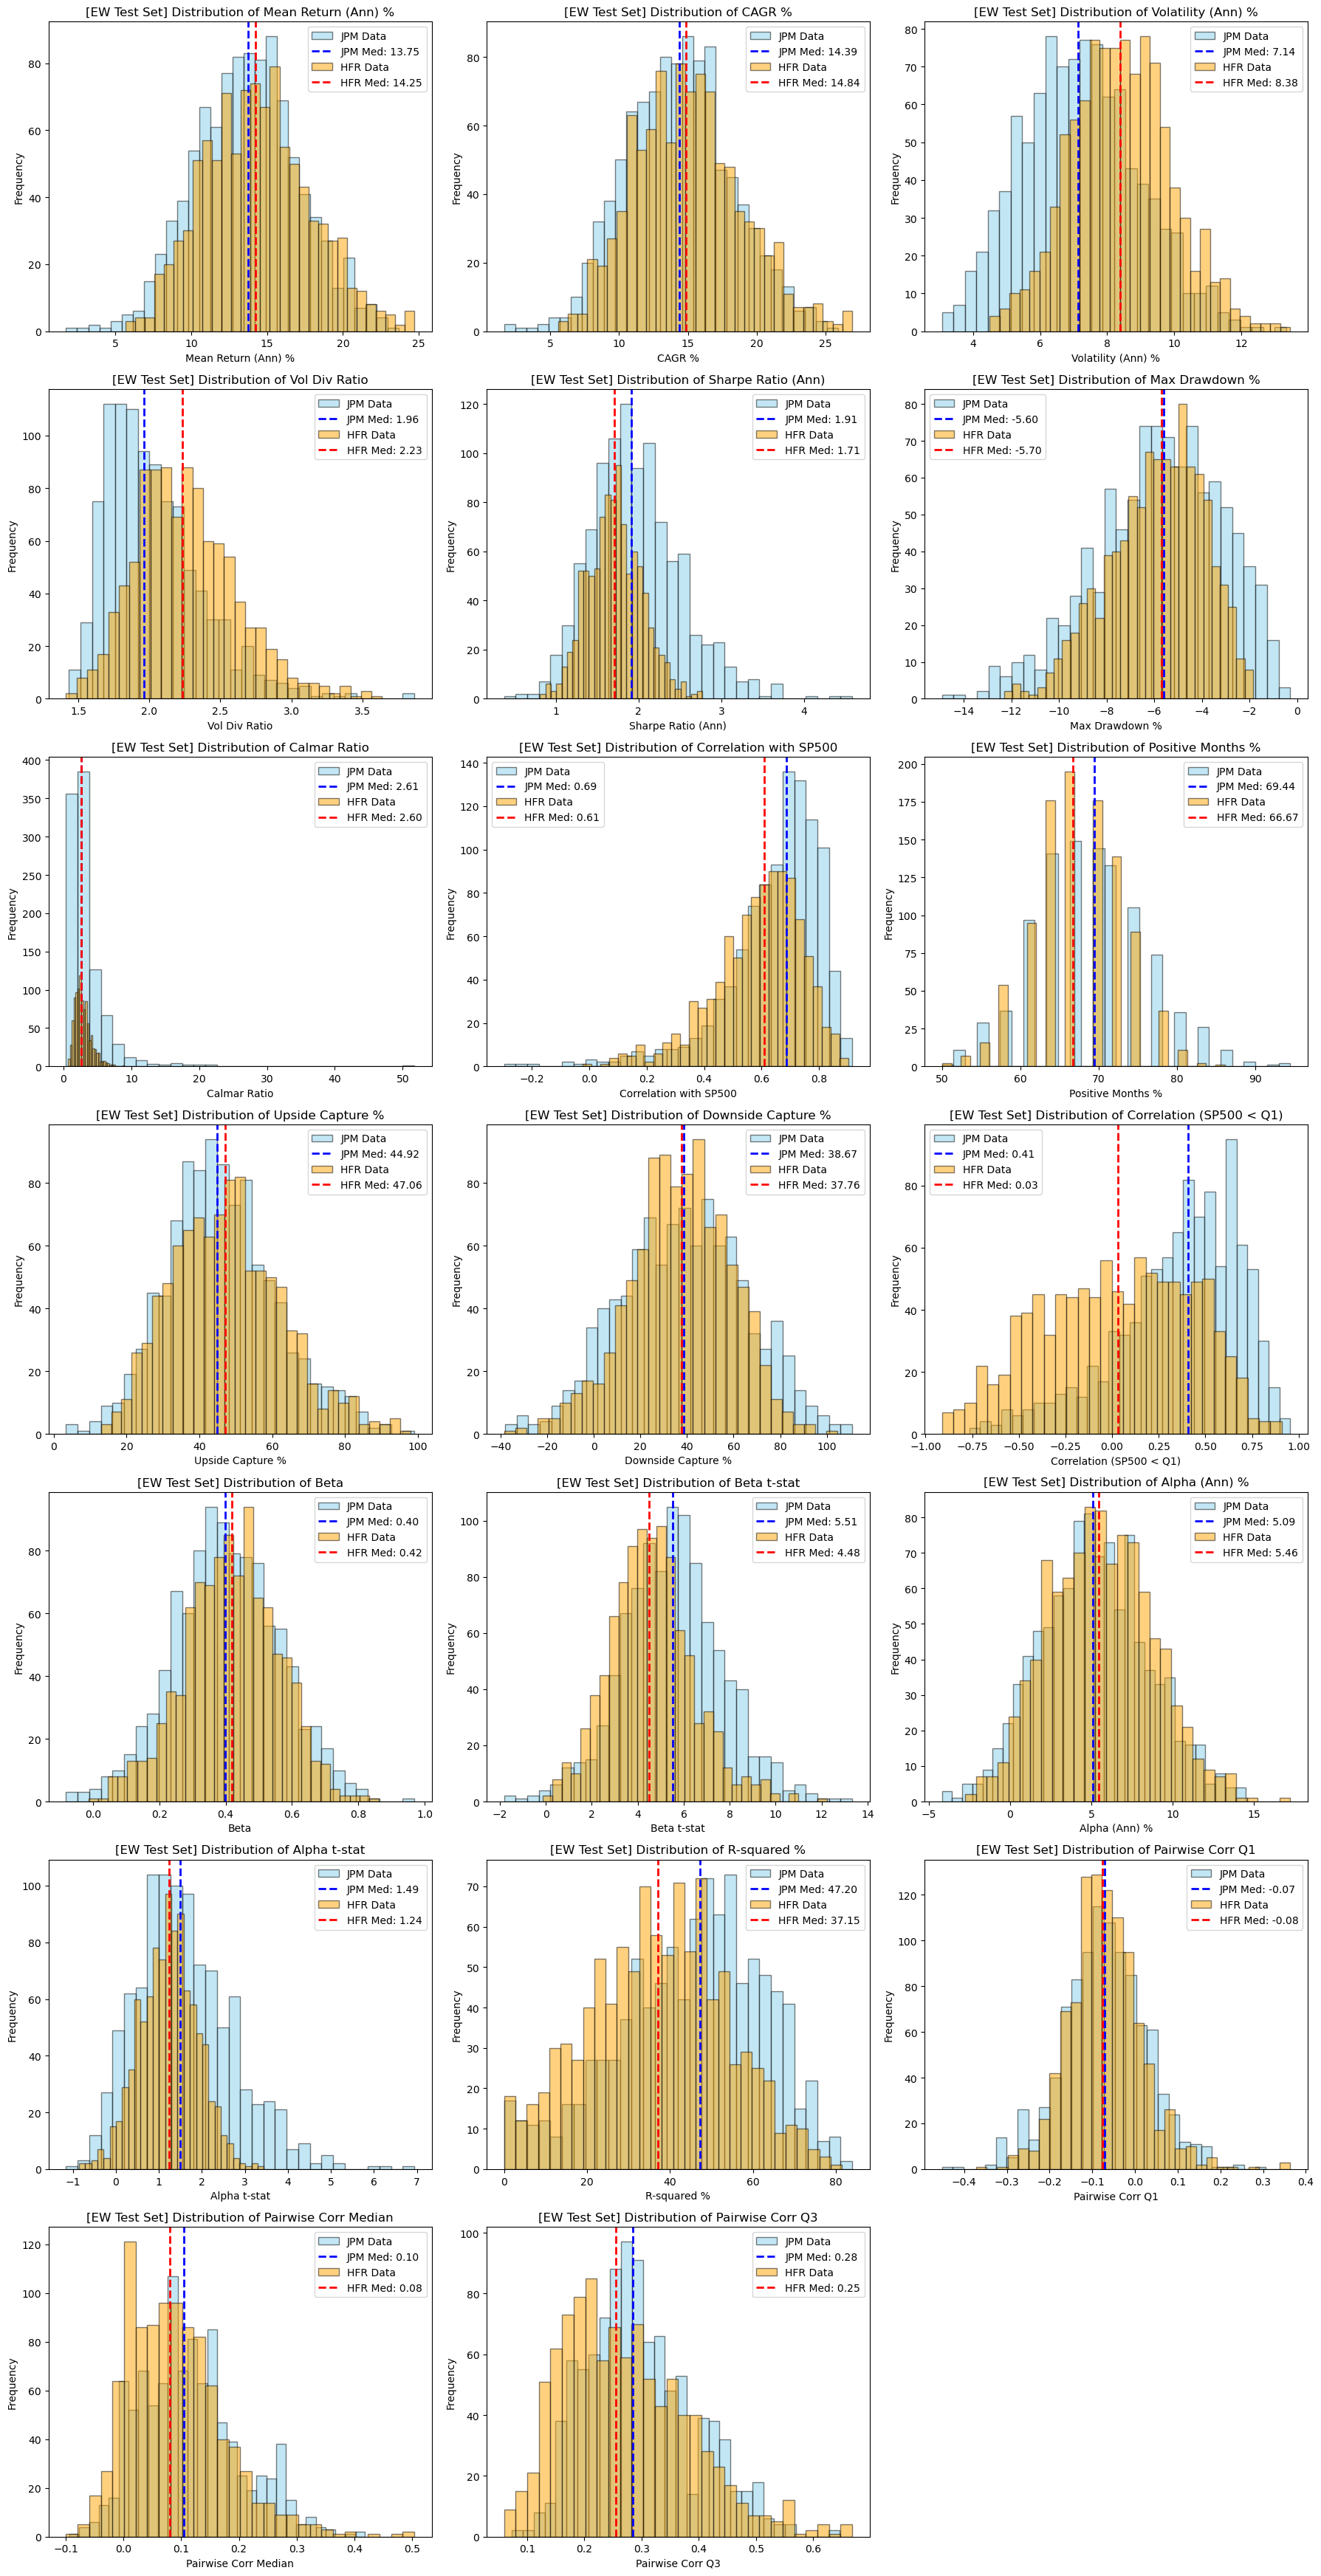

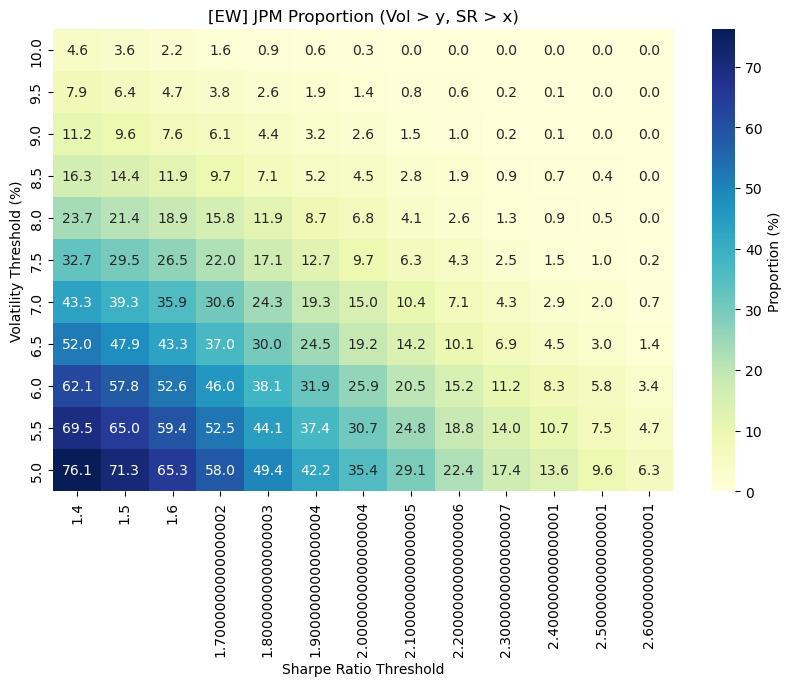

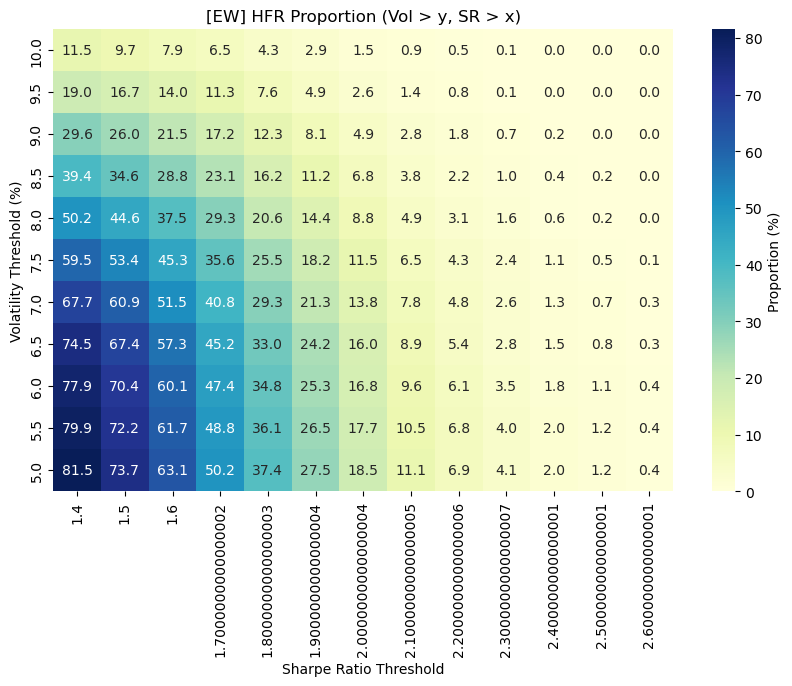

In [7]:
np.random.seed(42)
res_jpm_10_ew = run_bootstrap_n(jpm_test, sp500_test, 10, n_boot=1000, weight_scheme='ew')
res_hfr_10_ew = run_bootstrap_n(hfr_test, sp500_test, 10, n_boot=1000, weight_scheme='ew')

plot_distributions(res_jpm_10_ew, res_hfr_10_ew, title_prefix="[EW Test Set]")

run_grid_searches(res_jpm_10_ew, res_hfr_10_ew, label_1='JPM', label_2='HFR', title_prefix='[EW]')


Scaling sizes (EW): 100%|██████████| 13/13 [00:43<00:00,  3.38s/it]


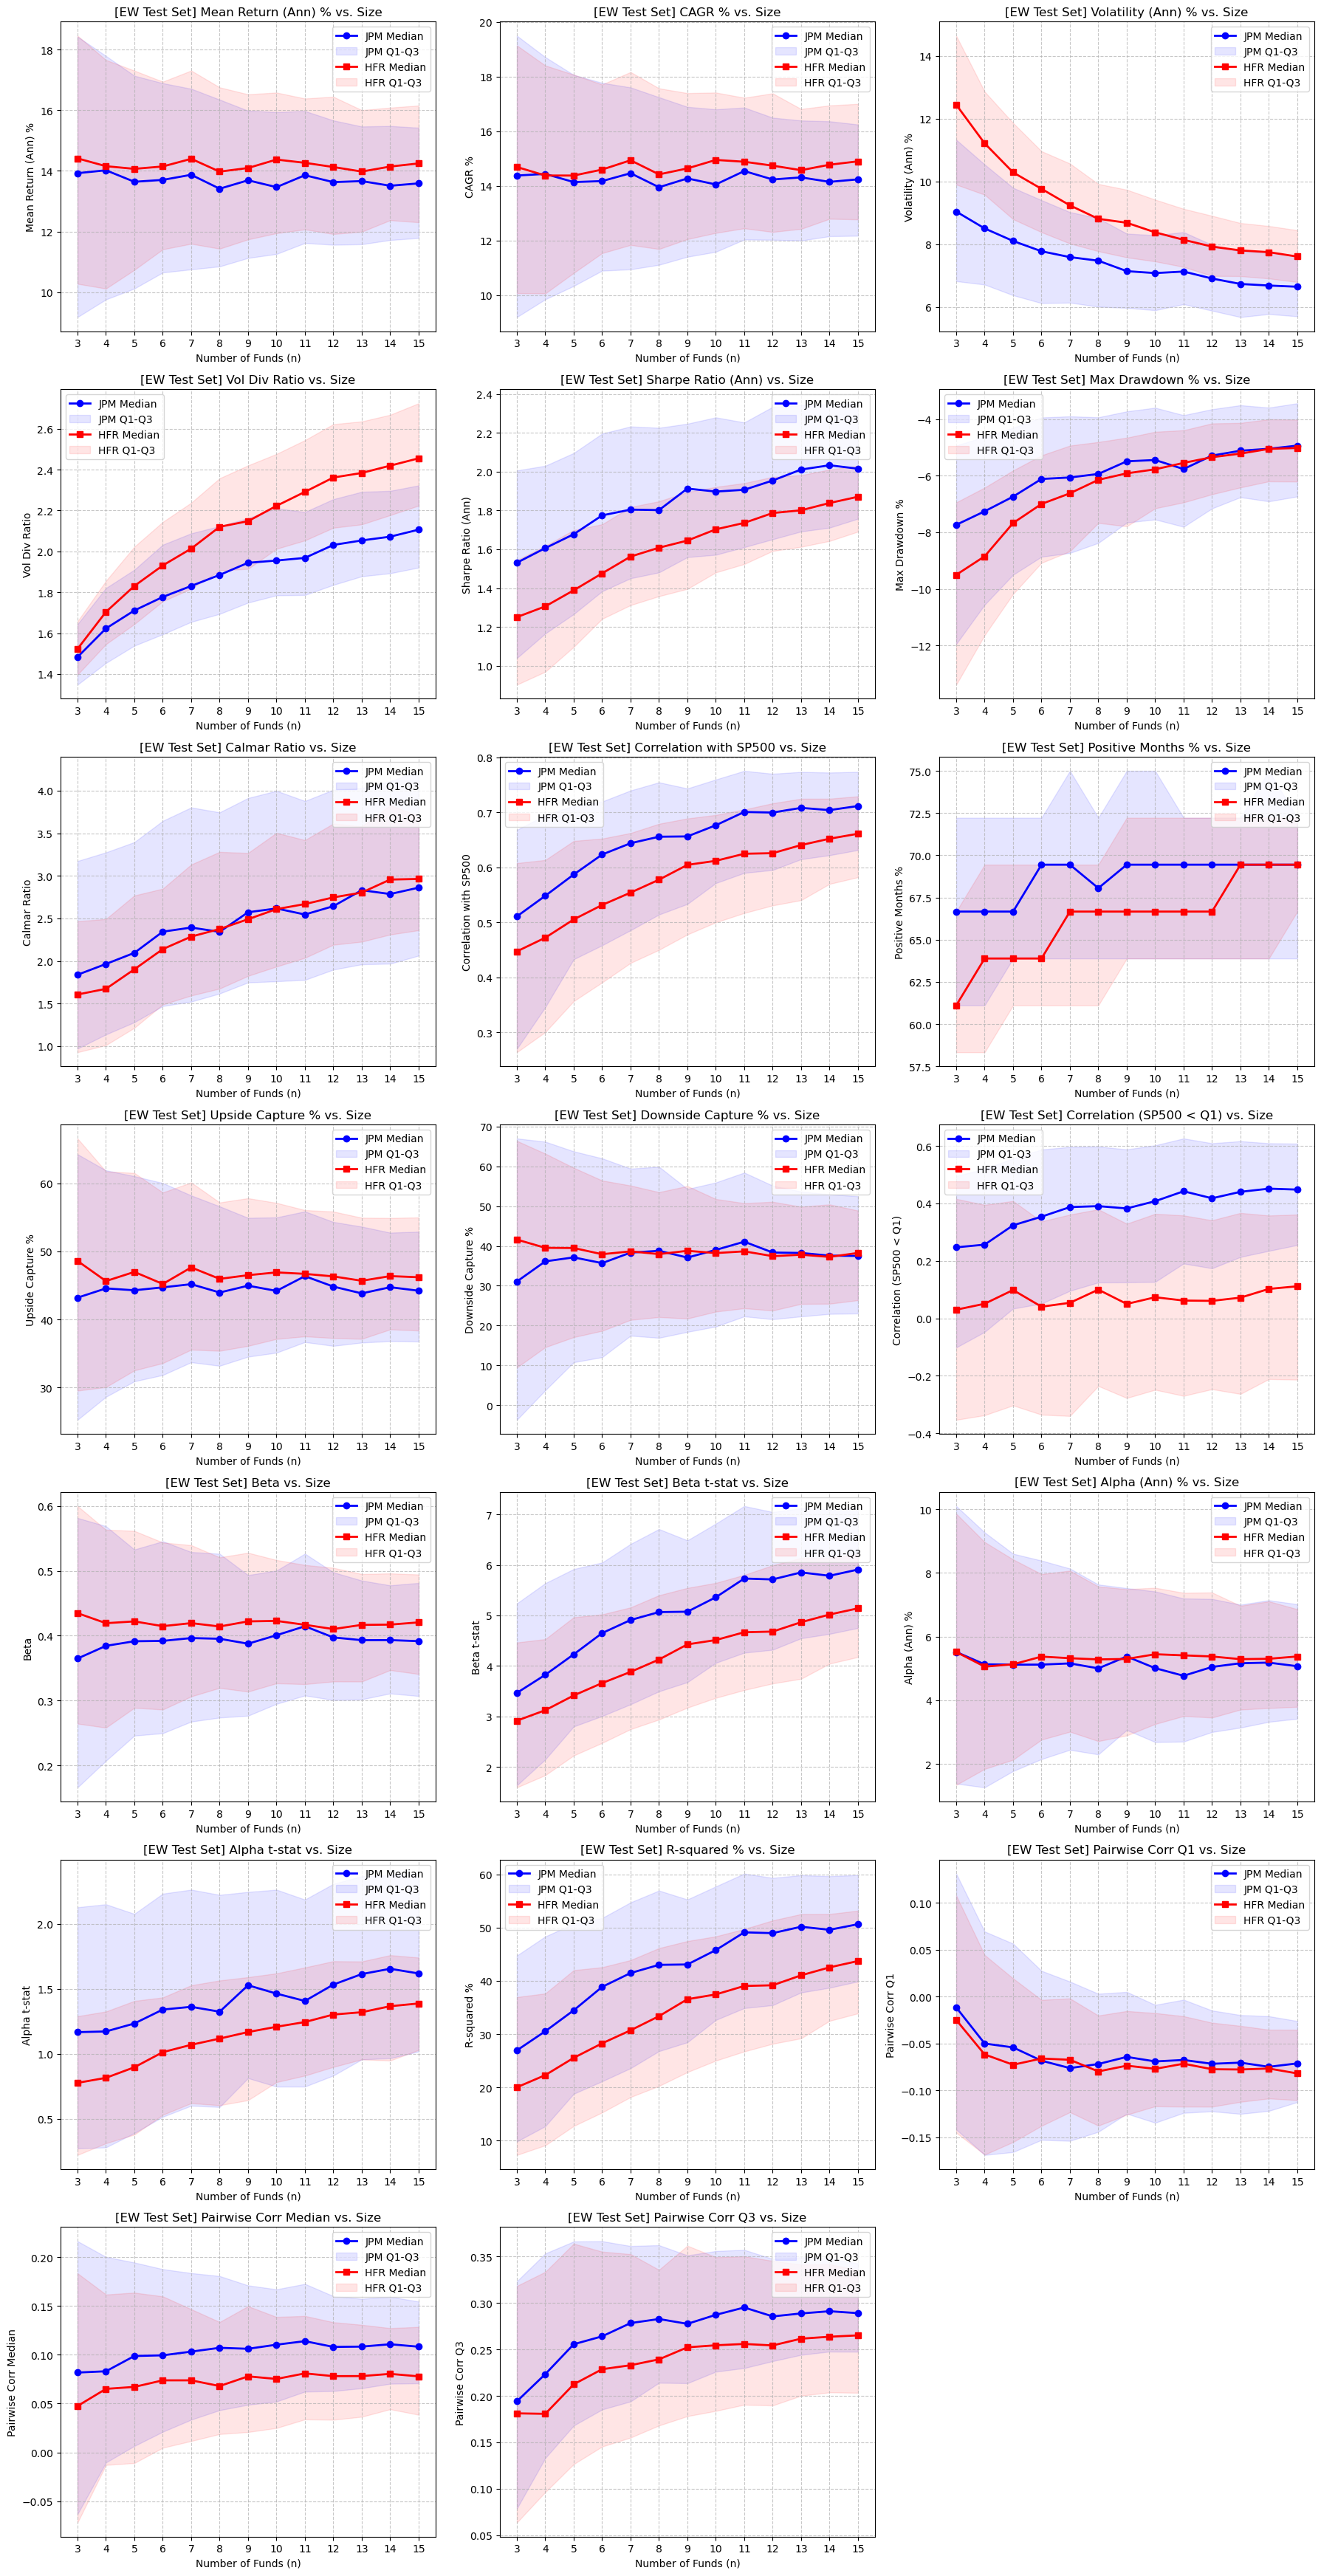

In [8]:
np.random.seed(42)
df_q_jpm_ew, df_q_hfr_ew = run_scaling_analysis(jpm_test, hfr_test, sp500_test, weight_scheme='ew')
plot_scaling(df_q_jpm_ew, df_q_hfr_ew, title_prefix="[EW Test Set]")


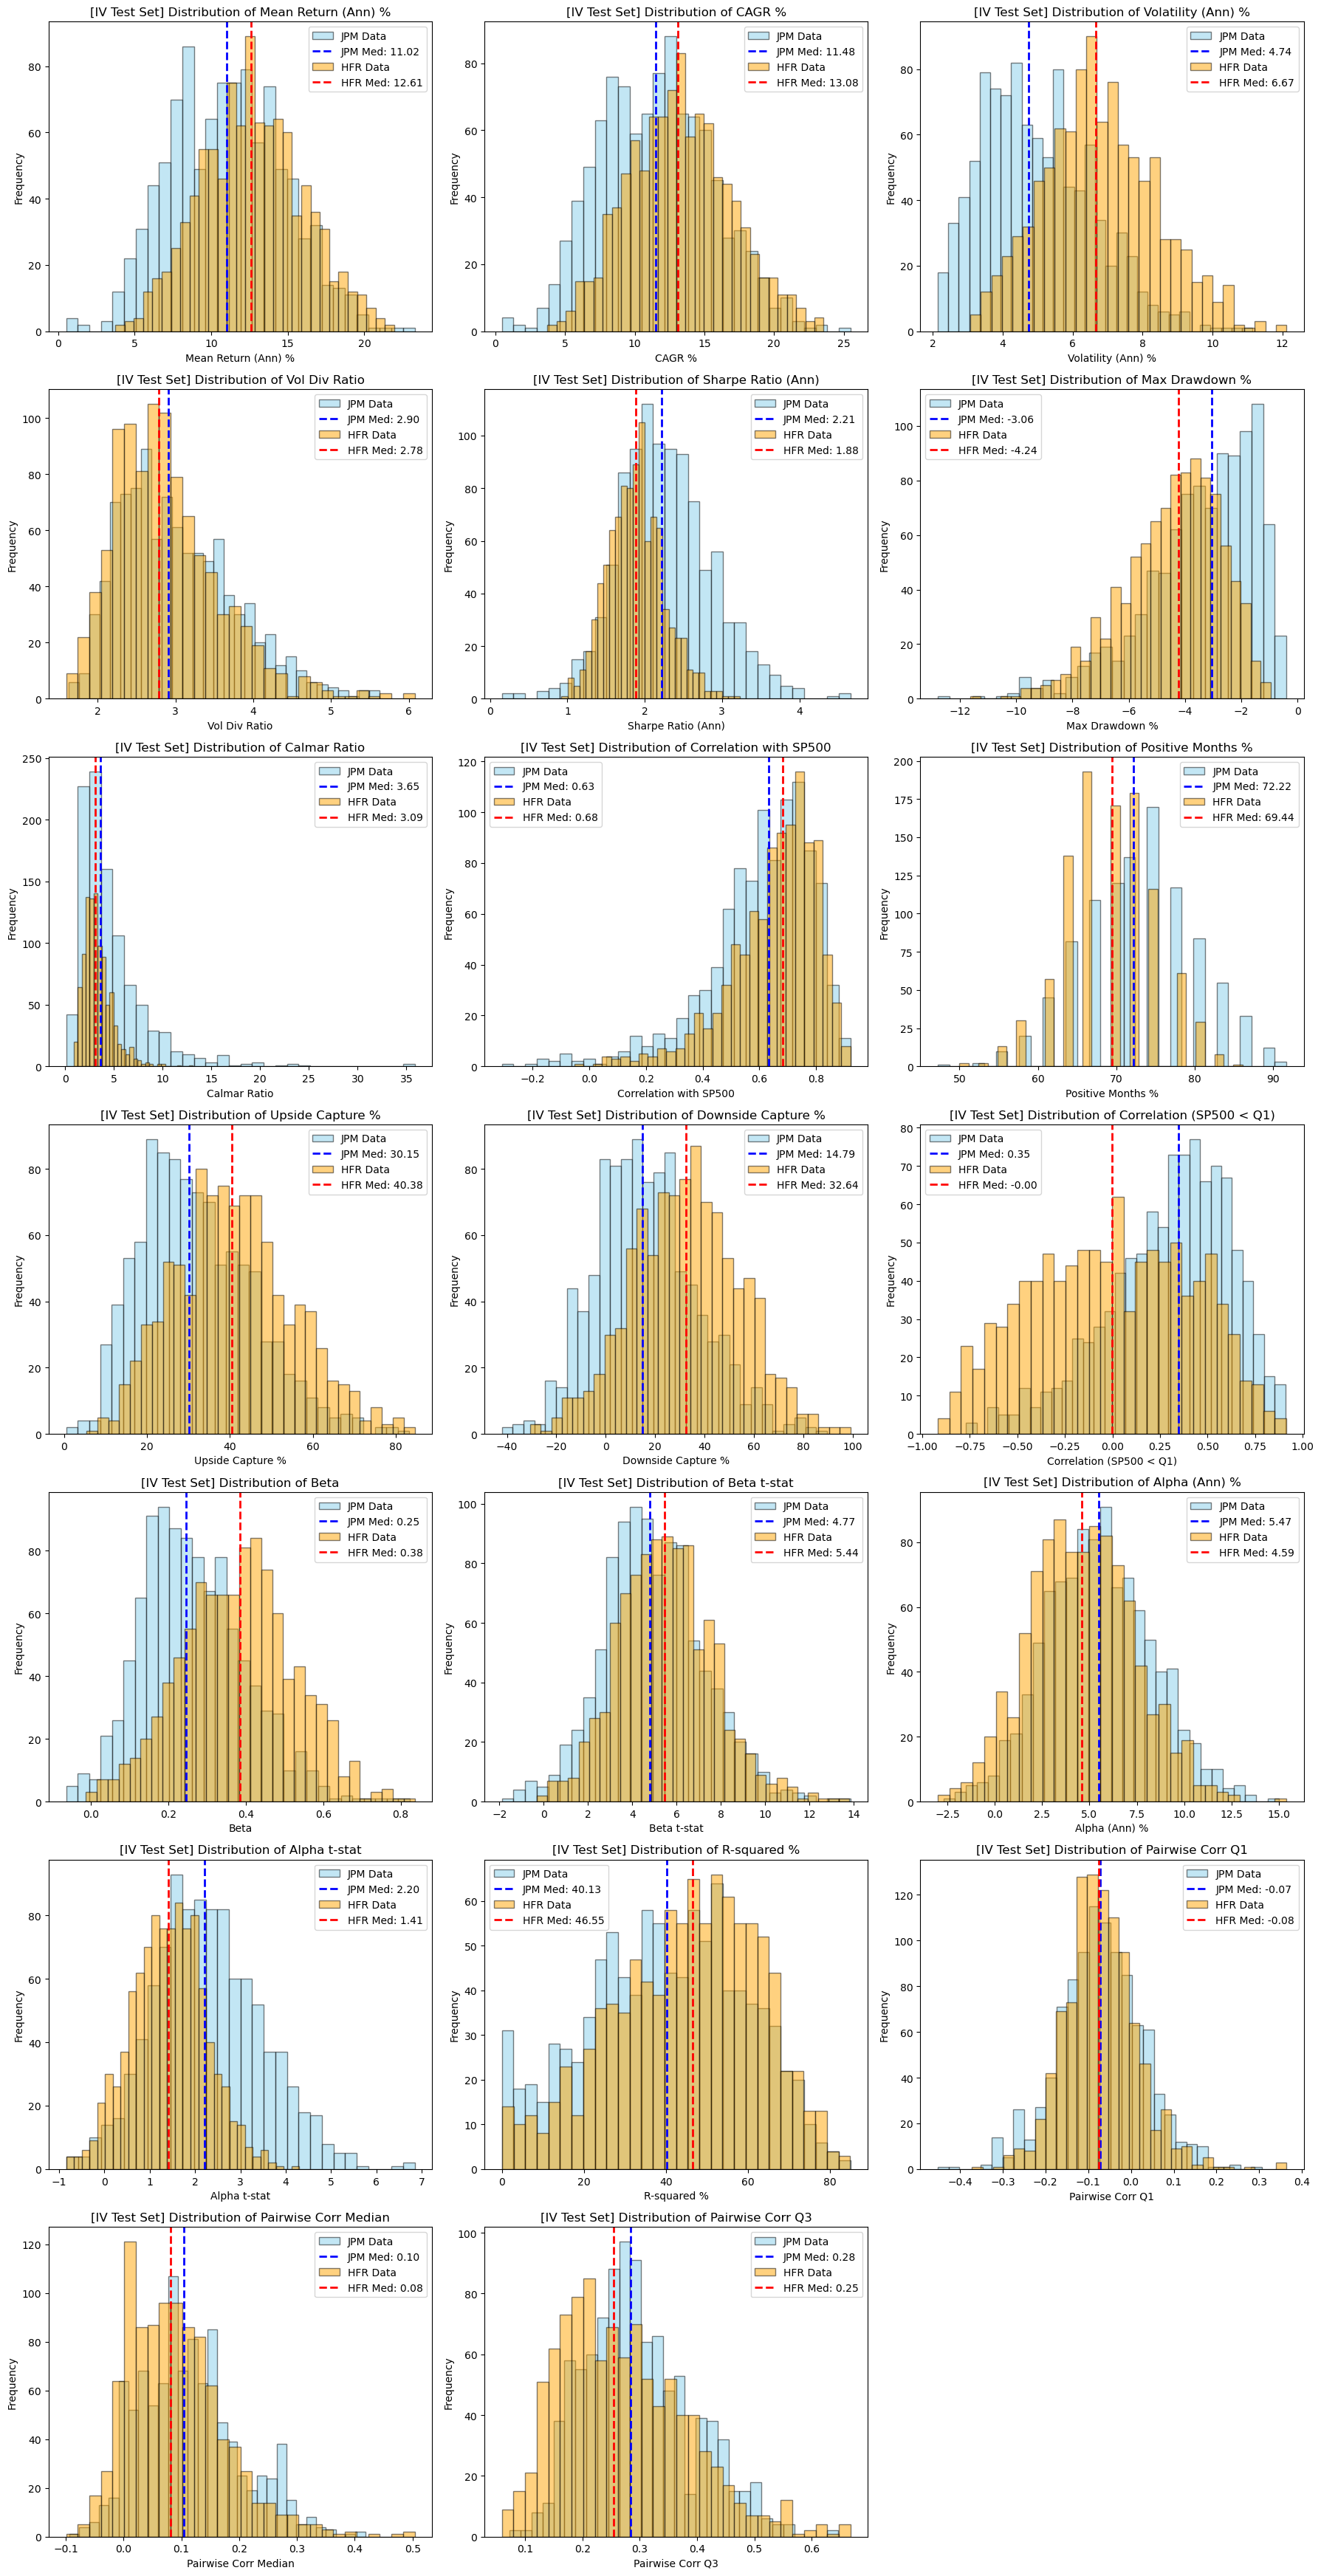

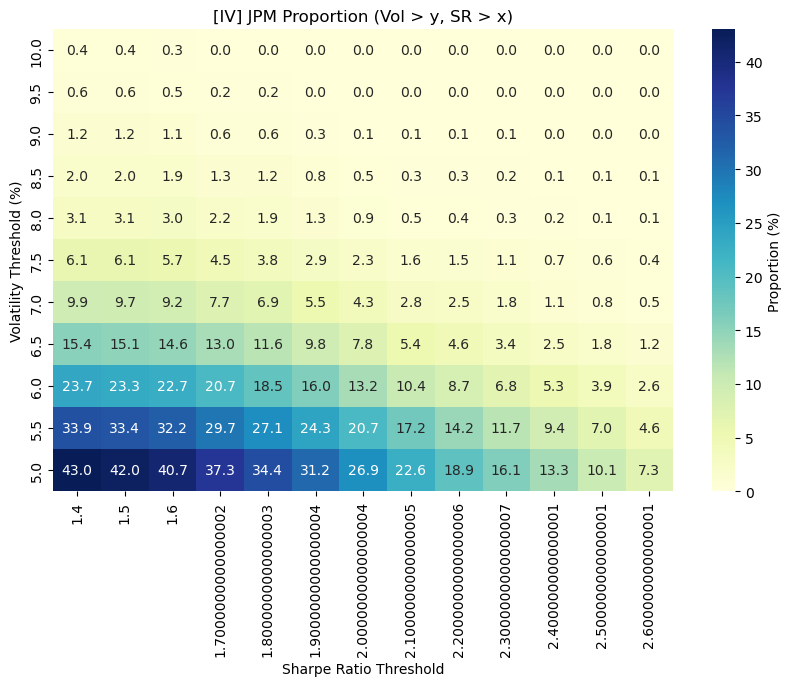

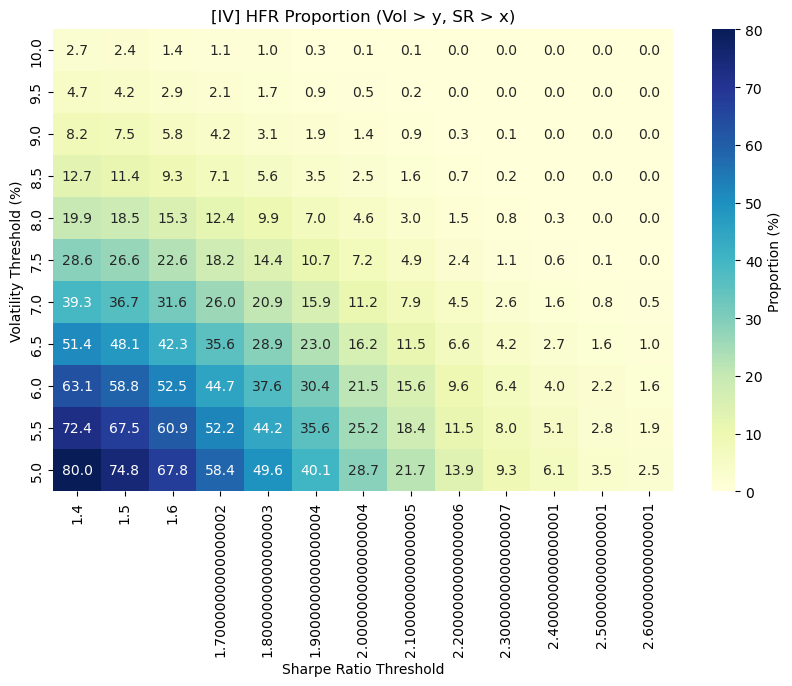

In [9]:
np.random.seed(42)
res_jpm_10_iv = run_bootstrap_n(jpm_test, sp500_test, 10, n_boot=1000, weight_scheme='iv')
res_hfr_10_iv = run_bootstrap_n(hfr_test, sp500_test, 10, n_boot=1000, weight_scheme='iv')

plot_distributions(res_jpm_10_iv, res_hfr_10_iv, title_prefix="[IV Test Set]")

run_grid_searches(res_jpm_10_iv, res_hfr_10_iv, label_1='JPM', label_2='HFR', title_prefix='[IV]')


Scaling sizes (IV): 100%|██████████| 13/13 [00:46<00:00,  3.54s/it]


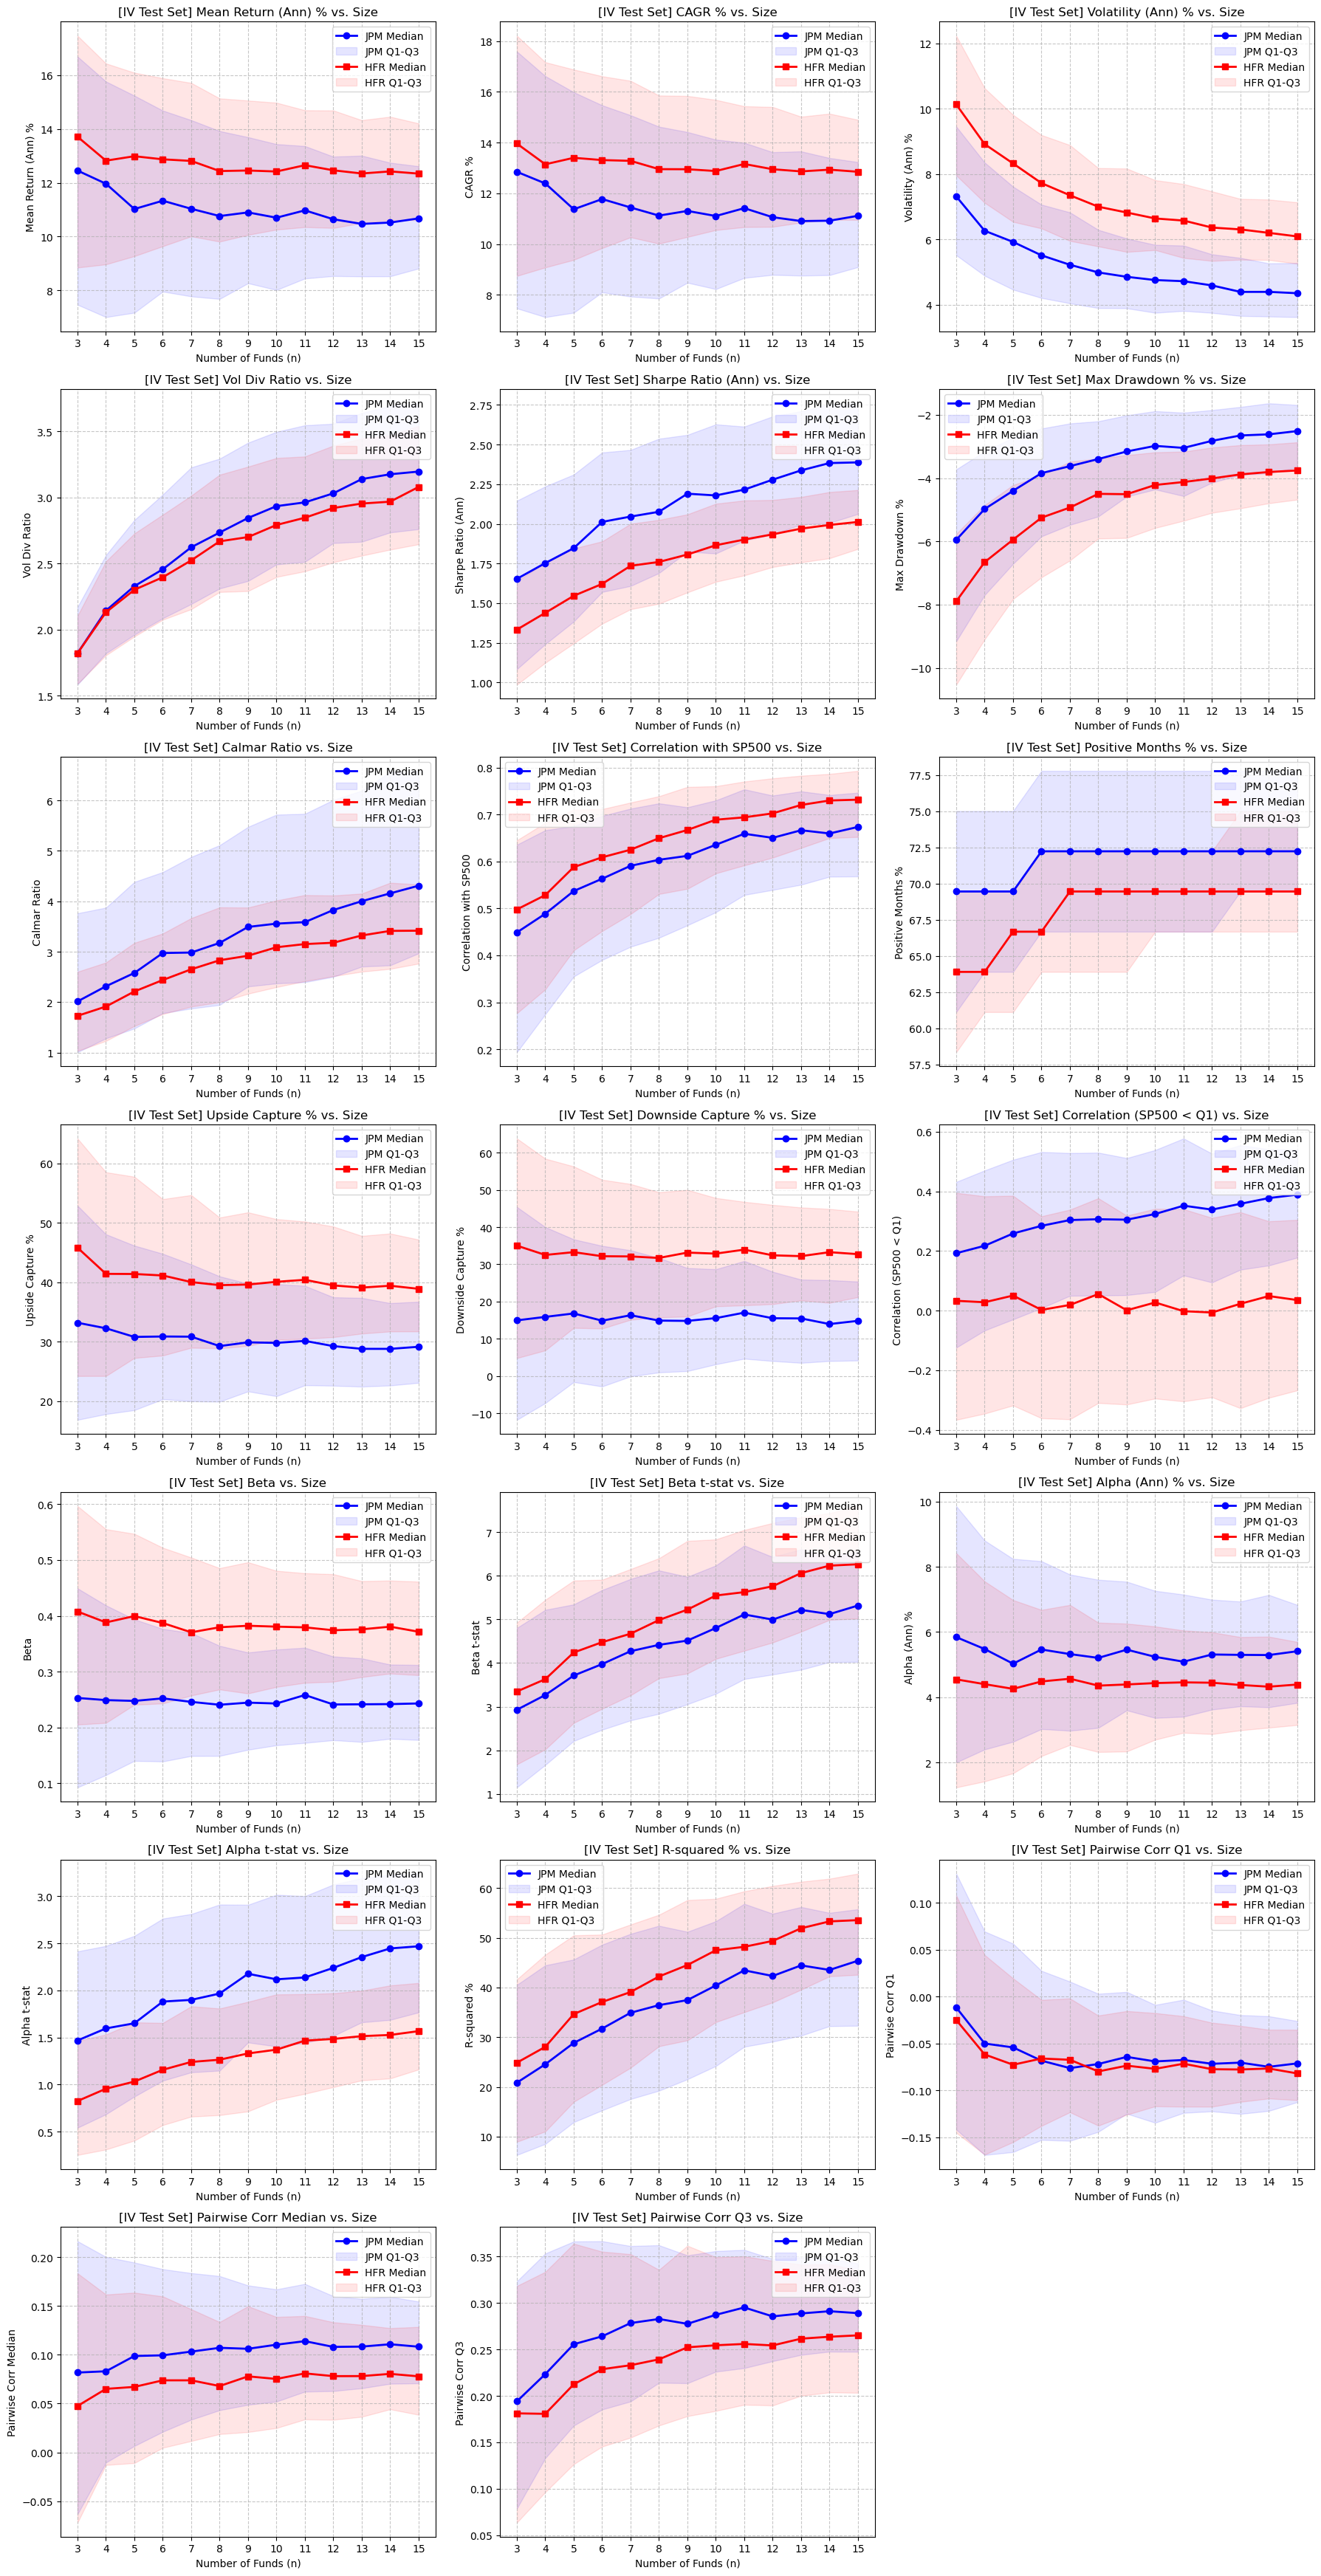

In [10]:
np.random.seed(42)
df_q_jpm_iv, df_q_hfr_iv = run_scaling_analysis(jpm_test, hfr_test, sp500_test, weight_scheme='iv')
plot_scaling(df_q_jpm_iv, df_q_hfr_iv, title_prefix="[IV Test Set]")


In [11]:
def create_comparison_table(res_jpm_ew, res_hfr_ew, res_jpm_iv, res_hfr_iv):
    datasets = {
        ('JPM', 'EW'): res_jpm_ew,
        ('HFR', 'EW'): res_hfr_ew,
        ('JPM', 'IV'): res_jpm_iv,
        ('HFR', 'IV'): res_hfr_iv
    }
    
    summary_data = {}
    
    for (data_name, weight_scheme), df in datasets.items():
        if df.empty:
            continue
            
        for metric in metrics_to_plot:
            q1 = df[metric].quantile(0.25)
            median = df[metric].median()
            q3 = df[metric].quantile(0.75)
            
            summary_data[(data_name, weight_scheme, 'Q1', metric)] = q1
            summary_data[(data_name, weight_scheme, 'Median', metric)] = median
            summary_data[(data_name, weight_scheme, 'Q3', metric)] = q3
            
    # Convert to a multi-index Series
    summary_series = pd.Series(summary_data)
    summary_series.index.names = ['Dataset', 'Weighting', 'Statistic', 'Metric']
    
    # Unstack the columns we want at the top
    summary_df = summary_series.unstack(level=['Dataset', 'Weighting', 'Statistic'])
    
    # Reorder columns explicitly for logical readability
    summary_df = summary_df.reindex(columns=['JPM', 'HFR'], level='Dataset')
    summary_df = summary_df.reindex(columns=['EW', 'IV'], level='Weighting')
    summary_df = summary_df.reindex(columns=['Q1', 'Median', 'Q3'], level='Statistic')
    
    # Reorder index exactly as defined in metrics_to_plot
    summary_df = summary_df.reindex(metrics_to_plot)
    
    return summary_df

comparison_table = create_comparison_table(res_jpm_10_ew, res_hfr_10_ew, res_jpm_10_iv, res_hfr_10_iv)

# Display standard formatted table
display(comparison_table)


Dataset                         JPM                                   \
Weighting                        EW                               IV   
Statistic                        Q1     Median         Q3         Q1   
Metric                                                                 
Mean Return (Ann) %       11.251576  13.752680  15.884535   8.205081   
CAGR %                    11.589478  14.386561  16.774108   8.403424   
Volatility (Ann) %         5.972845   7.135992   8.343946   3.736542   
Vol Div Ratio              1.776593   1.962229   2.207823   2.453255   
Sharpe Ratio (Ann)         1.601802   1.908107   2.278827   1.862227   
Max Drawdown %            -7.557315  -5.598829  -3.752684  -4.512567   
Calmar Ratio               1.809032   2.612303   3.875157   2.404220   
Correlation with SP500     0.574050   0.687044   0.762360   0.511645   
Positive Months %         63.888889  69.444444  75.000000  66.666667   
Upside Capture %          35.888239  44.921150  55.167836  21.798500   
Downside Capture %        19.393341  38.666840  57.510698   1.570094   
Correlation (SP500 < Q1)   0.169867   0.407663   0.618977   0.098196   
Beta                       0.295872   0.397610   0.506245   0.163711   
Beta t-stat                4.087904   5.513406   6.868974   3.472283   
Alpha (Ann) %              2.871997   5.086414   7.394381   3.496812   
Alpha t-stat               0.815101   1.491305   2.280559   1.472638   
R-squared %               32.953336  47.203019  58.119210  26.178034   
Pairwise Corr Q1          -0.135856  -0.071555  -0.004343  -0.135856   
Pairwise Corr Median       0.052280   0.104635   0.163622   0.052280   
Pairwise Corr Q3           0.228940   0.284664   0.354564   0.228940   

Dataset                                               HFR             \
Weighting                                              EW              
Statistic                    Median         Q3         Q1     Median   
Metric                                                                 
Mean Return (Ann) %       11.021063  13.653323  11.867250  14.253667   
CAGR %                    11.484509  14.310198  12.235566  14.835058   
Volatility (Ann) %         4.740945   6.037947   7.375863   8.383557   
Vol Div Ratio              2.903197   3.510346   2.002965   2.232922   
Sharpe Ratio (Ann)         2.214229   2.637934   1.490863   1.707653   
Max Drawdown %            -3.063269  -1.883141  -7.193662  -5.695766   
Calmar Ratio               3.650841   5.759356   1.966221   2.603016   
Correlation with SP500     0.633462   0.732509   0.498110   0.609517   
Positive Months %         72.222222  77.777778  63.888889  66.666667   
Upside Capture %          30.152957  40.882554  36.453172  47.061547   
Downside Capture %        14.785101  28.451277  23.994488  37.757236   
Correlation (SP500 < Q1)   0.345631   0.539923  -0.287863   0.031909   
Beta                       0.245986   0.346161   0.325441   0.419266   
Beta t-stat                4.773600   6.274228   3.349567   4.483075   
Alpha (Ann) %              5.471736   7.378096   3.195147   5.460589   
Alpha t-stat               2.200896   3.045041   0.782116   1.244710   
R-squared %               40.127408  53.656951  24.811367  37.151050   
Pairwise Corr Q1          -0.071555  -0.004343  -0.122369  -0.075867   
Pairwise Corr Median       0.104635   0.163622   0.025317   0.080740   
Pairwise Corr Q3           0.284664   0.354564   0.186626   0.254853   

Dataset                                                               
Weighting                                   IV                        
Statistic                        Q3         Q1     Median         Q3  
Metric                                                                
Mean Return (Ann) %       16.591583  10.253774  12.614173  14.873214  
CAGR %                    17.441724  10.539702  13.083223  15.640646  
Volatility (Ann) %         9.395317   5.638488   6.666772   7.860529  
Vol Div Ratio              2.485422   2.39601

## 7. Whole Universe Baseline (2023-2025)

In [12]:
# Slice global data for the test period (Whole Universe)
jpm_test_universe = jpm_period.loc[test_start:test_end]
hfr_test_universe = hfr_period.loc[test_start:test_end]

print(f"JPM Universe Test Set Shape: {jpm_test_universe.shape}")
print(f"HFR Universe Test Set Shape: {hfr_test_universe.shape}")

np.random.seed(42)
# EW Bootstrap for Universe
res_jpm_10_ew_universe = run_bootstrap_n(jpm_test_universe, sp500_test, 10, n_boot=1000, weight_scheme='ew')
res_hfr_10_ew_universe = run_bootstrap_n(hfr_test_universe, sp500_test, 10, n_boot=1000, weight_scheme='ew')

np.random.seed(42)
# IV Bootstrap for Universe
res_jpm_10_iv_universe = run_bootstrap_n(jpm_test_universe, sp500_test, 10, n_boot=1000, weight_scheme='iv')
res_hfr_10_iv_universe = run_bootstrap_n(hfr_test_universe, sp500_test, 10, n_boot=1000, weight_scheme='iv')


JPM Universe Test Set Shape: (36, 348)
HFR Universe Test Set Shape: (36, 354)


In [13]:
def plot_universe_comparison_box(res_sel, res_uni, dataset_name, weight_scheme):
    n_metrics = len(metrics_to_plot)
    nrows = int(np.ceil(n_metrics / 3))
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 5 * nrows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        data_to_plot = []
        labels = []
        
        if not res_sel.empty:
            data_to_plot.append(res_sel[metric].dropna().values)
            labels.append("Vol/Ret Selection")
            
        if not res_uni.empty:
            data_to_plot.append(res_uni[metric].dropna().values)
            labels.append("Universe")
            
        if data_to_plot:
            sns.boxplot(data=data_to_plot, ax=ax, palette=["skyblue", "lightgray"])
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels)
            
        ax.set_title(f'{dataset_name} [{weight_scheme.upper()}] - {metric}')
        ax.set_ylabel(metric)

    for i in range(n_metrics, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

def plot_universe_comparison_hist(res_sel, res_uni, dataset_name, weight_scheme):
    n_metrics = len(metrics_to_plot)
    nrows = int(np.ceil(n_metrics / 3))
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 5 * nrows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        if not res_uni.empty:
            d_uni = res_uni[metric].dropna()
            ax.hist(d_uni, bins=30, color='gray', edgecolor='black', alpha=0.4, label='Universe')
            med_uni = d_uni.median()
            ax.axvline(med_uni, color='darkgray', linestyle='dashed', linewidth=2)
            
        if not res_sel.empty:
            d_sel = res_sel[metric].dropna()
            ax.hist(d_sel, bins=30, color='blue', edgecolor='black', alpha=0.5, label='Vol/Ret Selection')
            med_sel = d_sel.median()
            ax.axvline(med_sel, color='blue', linestyle='dashed', linewidth=2)
            
        ax.set_title(f'{dataset_name} [{weight_scheme.upper()}] - {metric}')
        ax.set_xlabel(metric)
        ax.set_ylabel('Frequency')
        ax.legend()

    for i in range(n_metrics, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()


### Visualizations (JPM EW)

JPM EW: Vol/Ret Selection vs Universe Boxplots


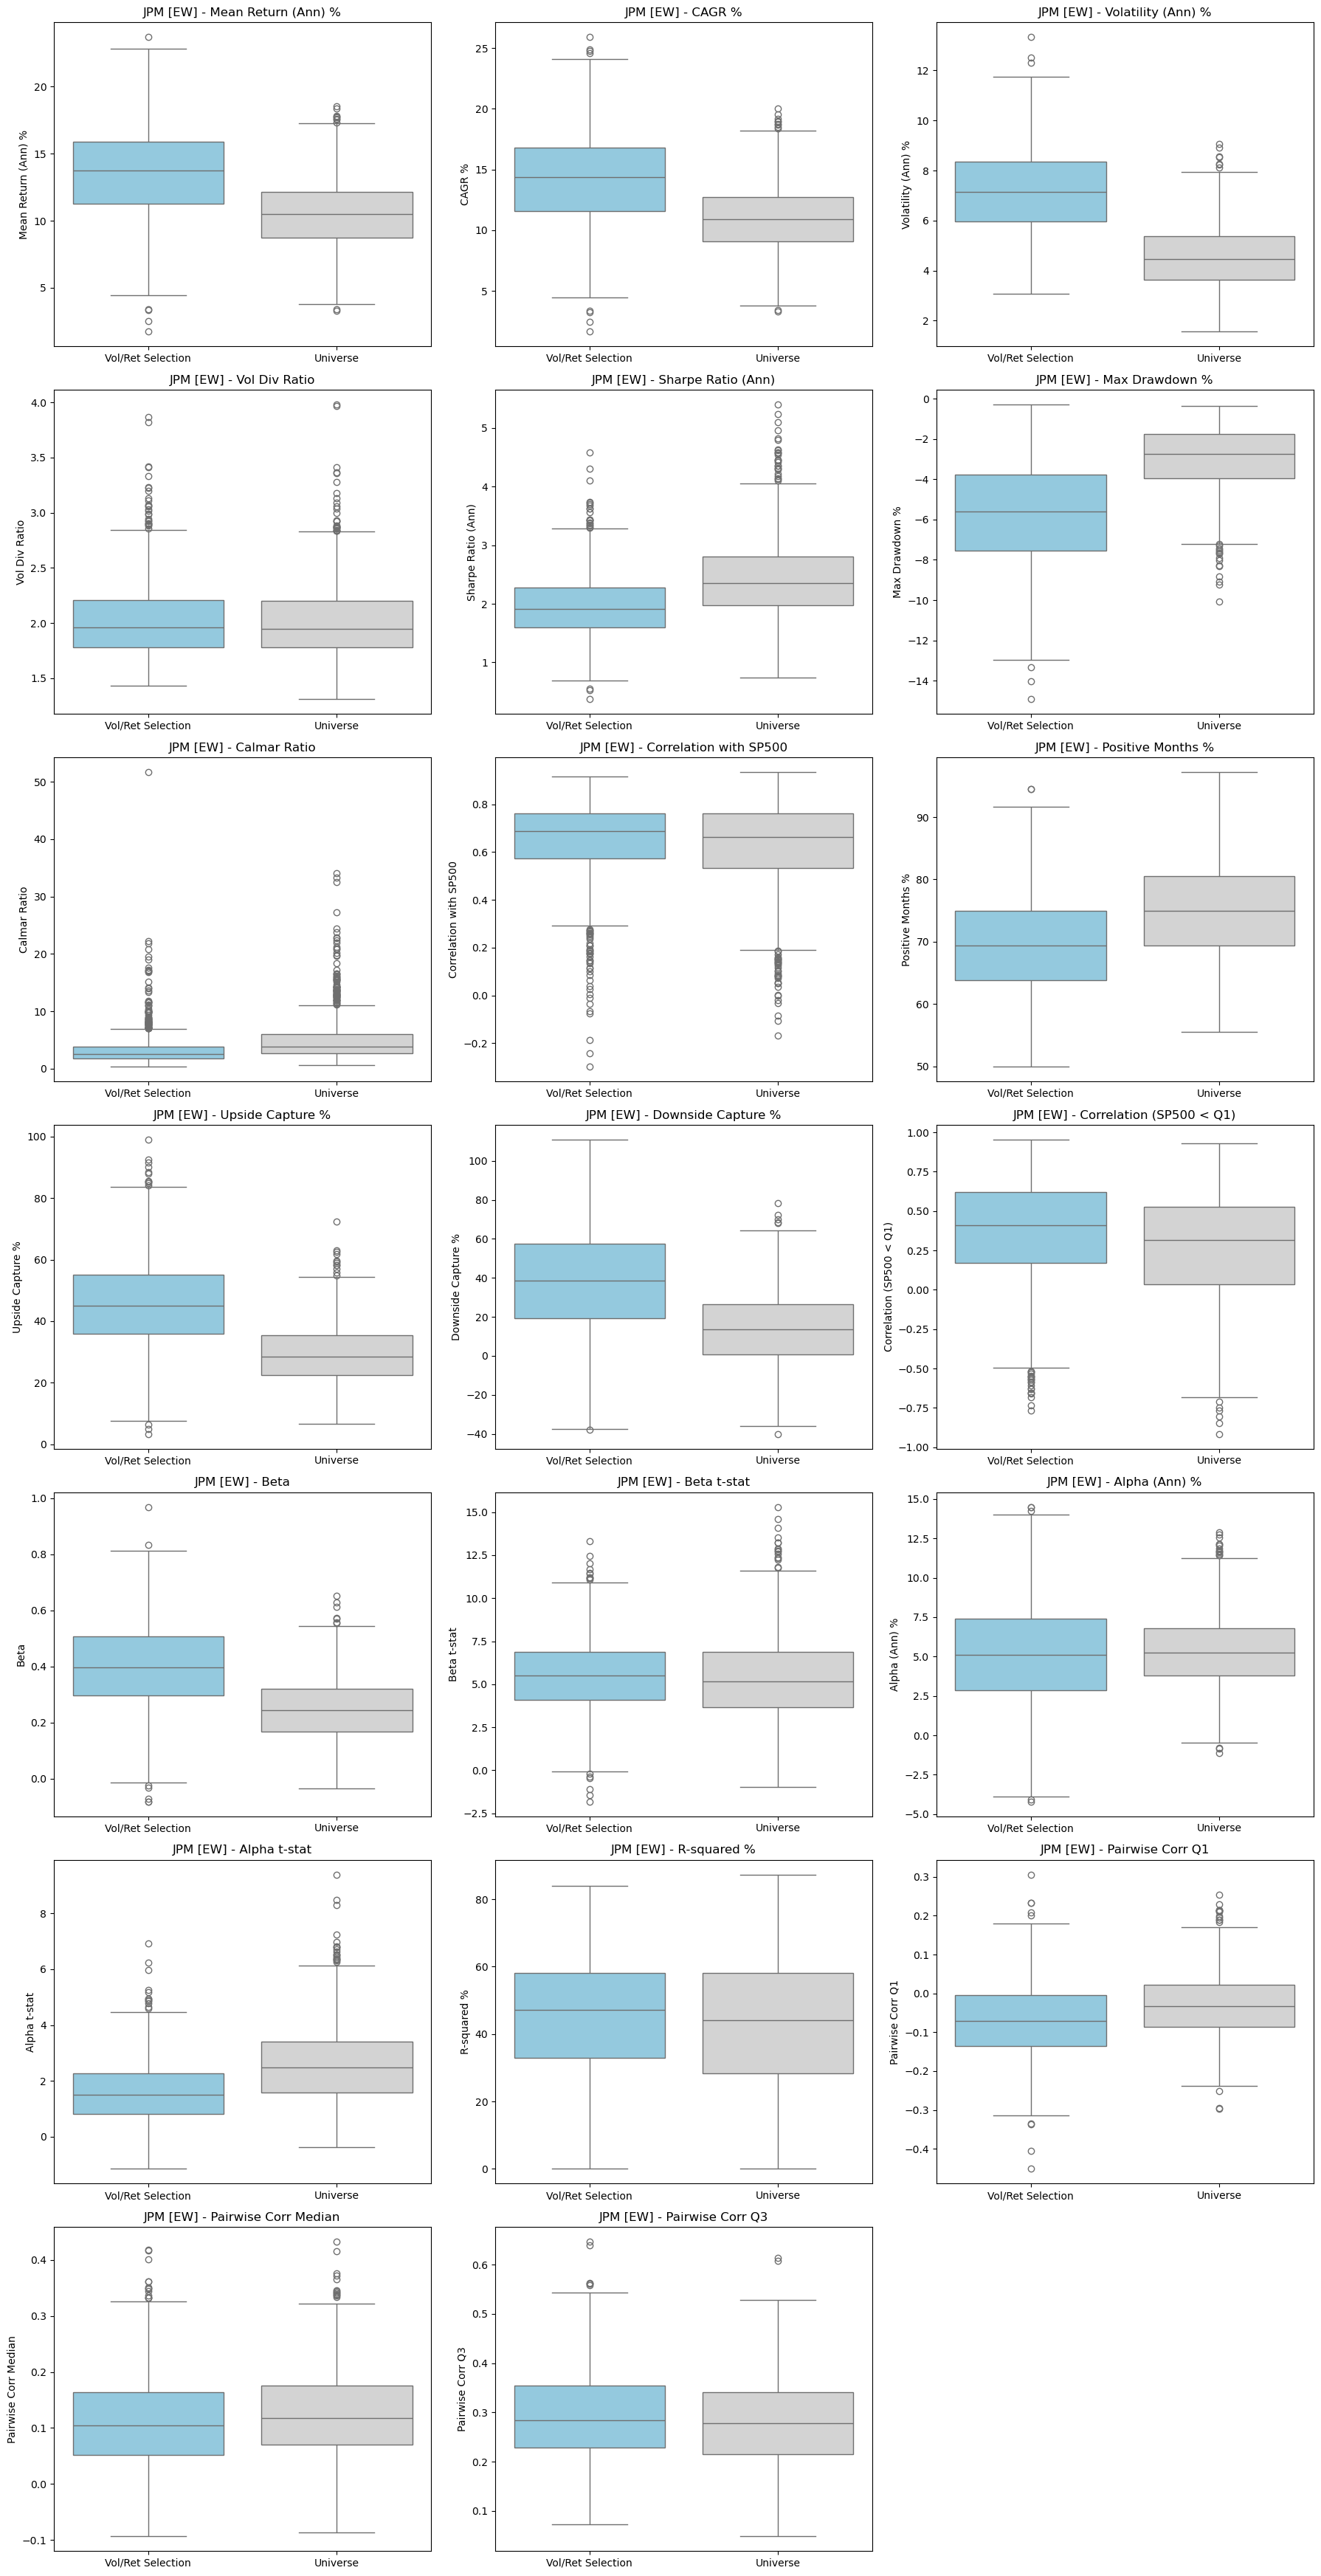

JPM EW: Vol/Ret Selection vs Universe Overlaid Histograms


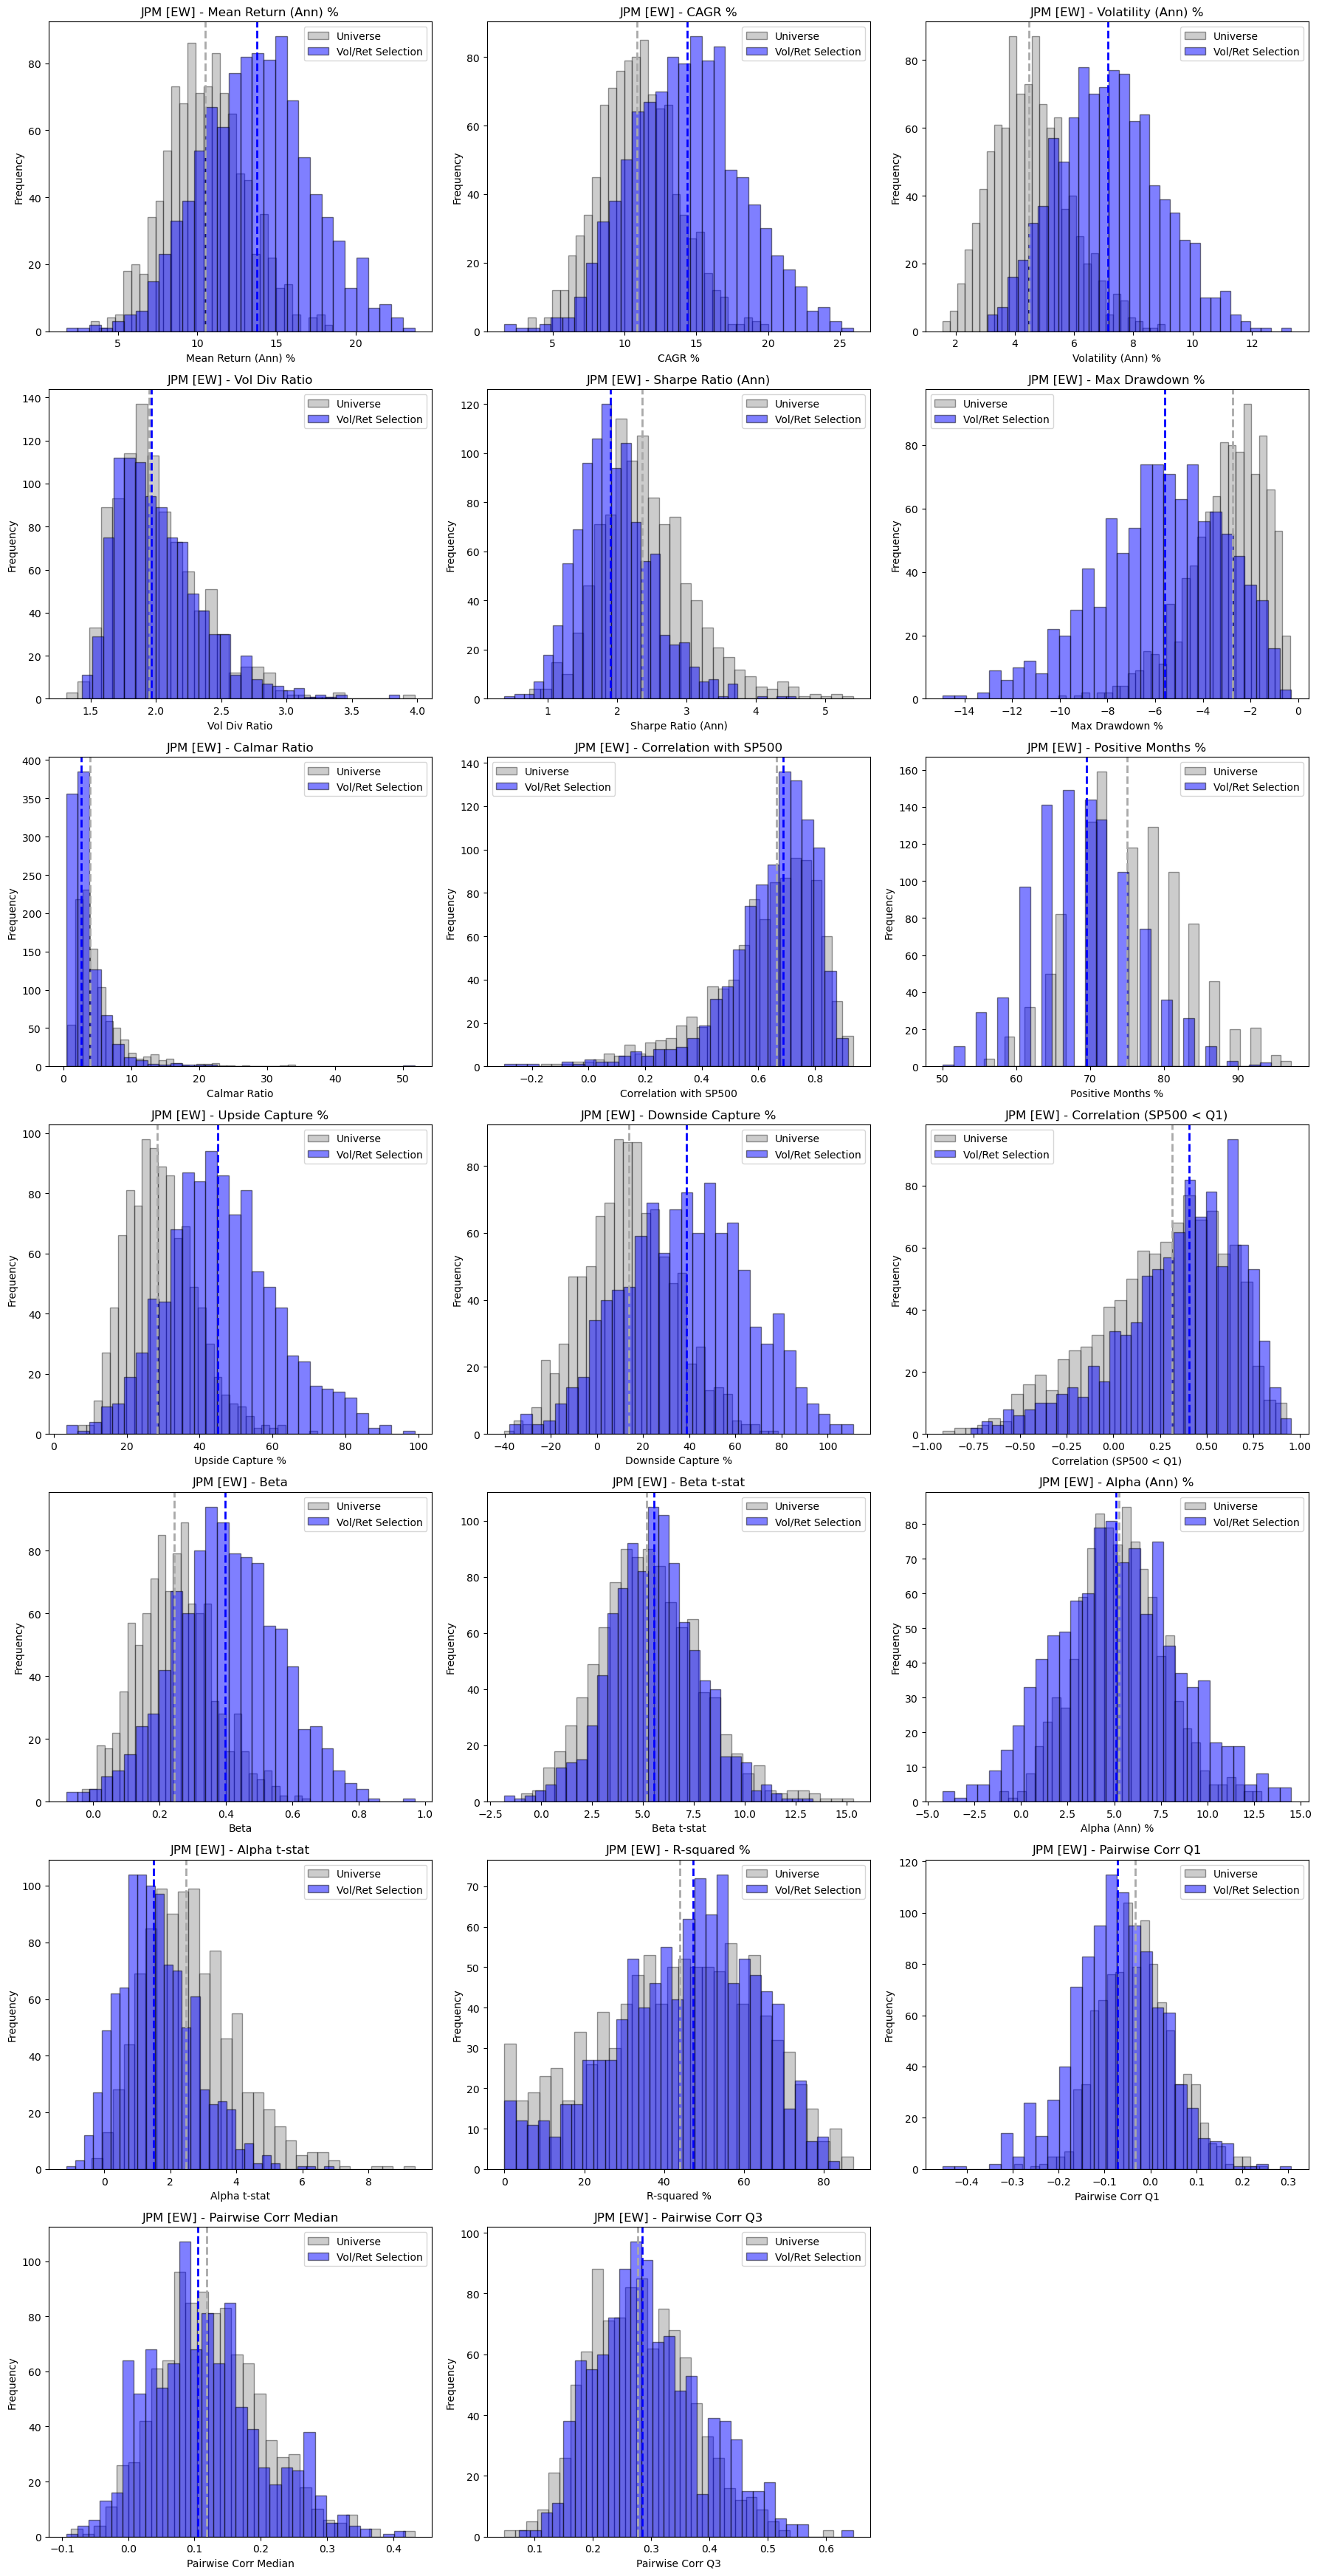

In [14]:
print("JPM EW: Vol/Ret Selection vs Universe Boxplots")
plot_universe_comparison_box(res_jpm_10_ew, res_jpm_10_ew_universe, "JPM", "EW")

print("JPM EW: Vol/Ret Selection vs Universe Overlaid Histograms")
plot_universe_comparison_hist(res_jpm_10_ew, res_jpm_10_ew_universe, "JPM", "EW")


### Visualizations (HFR EW)

HFR EW: Vol/Ret Selection vs Universe Boxplots


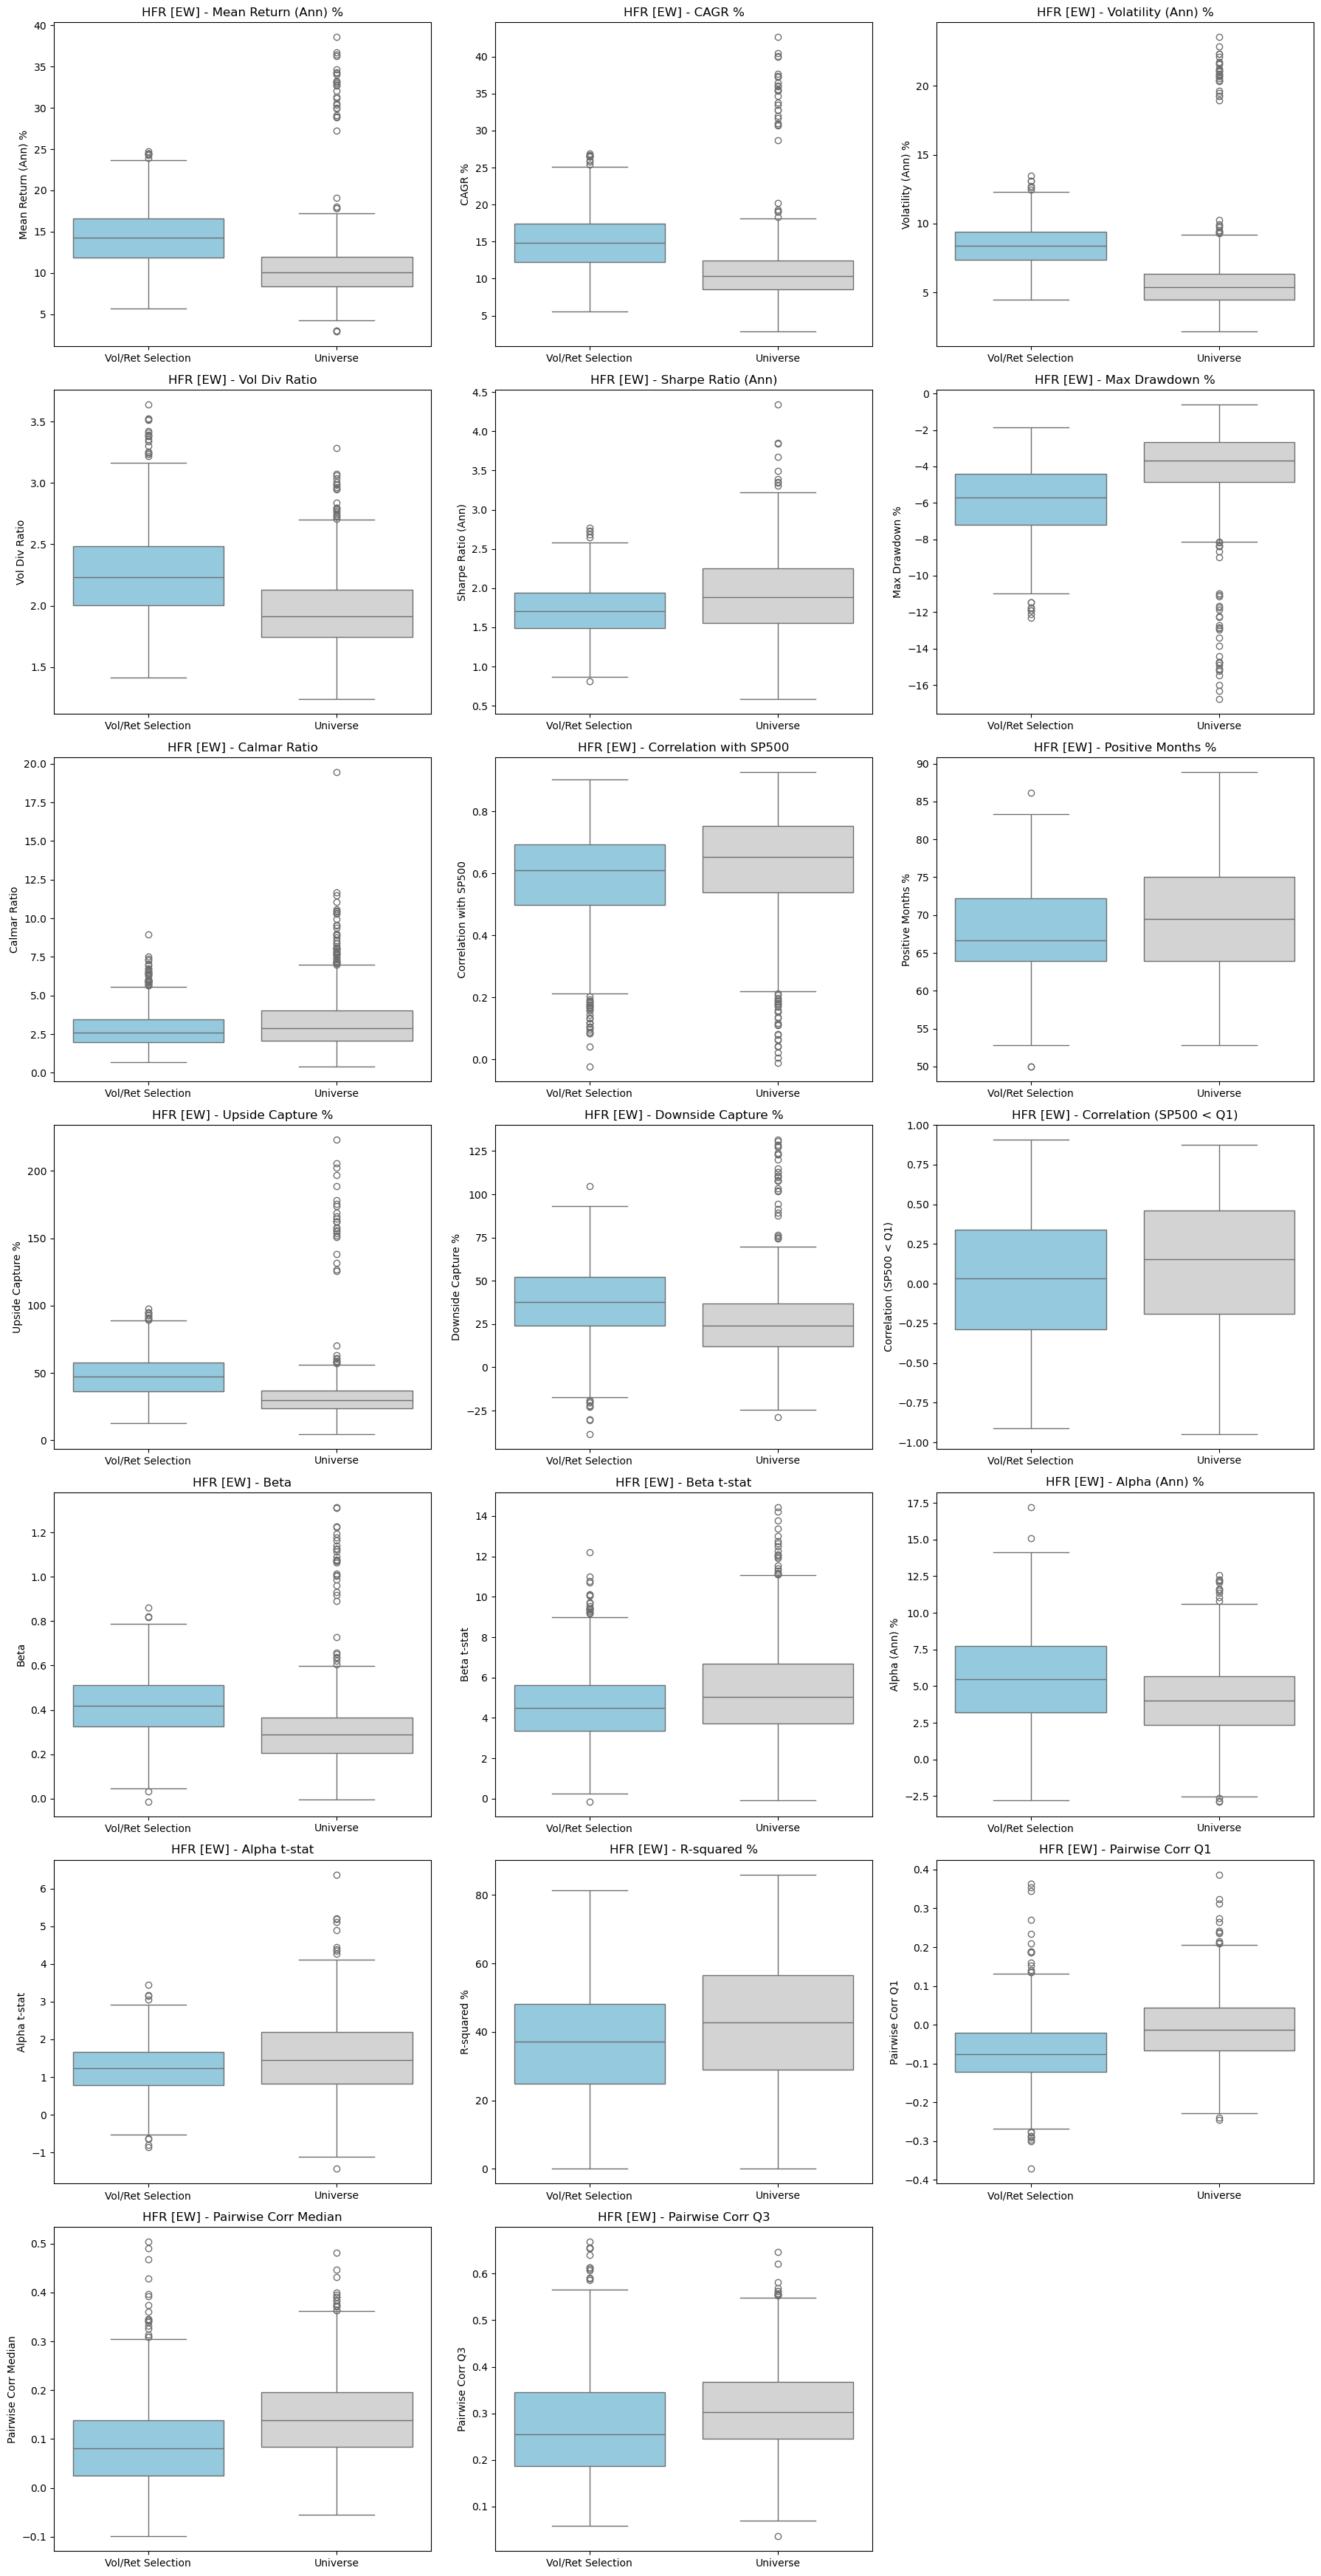

HFR EW: Vol/Ret Selection vs Universe Overlaid Histograms


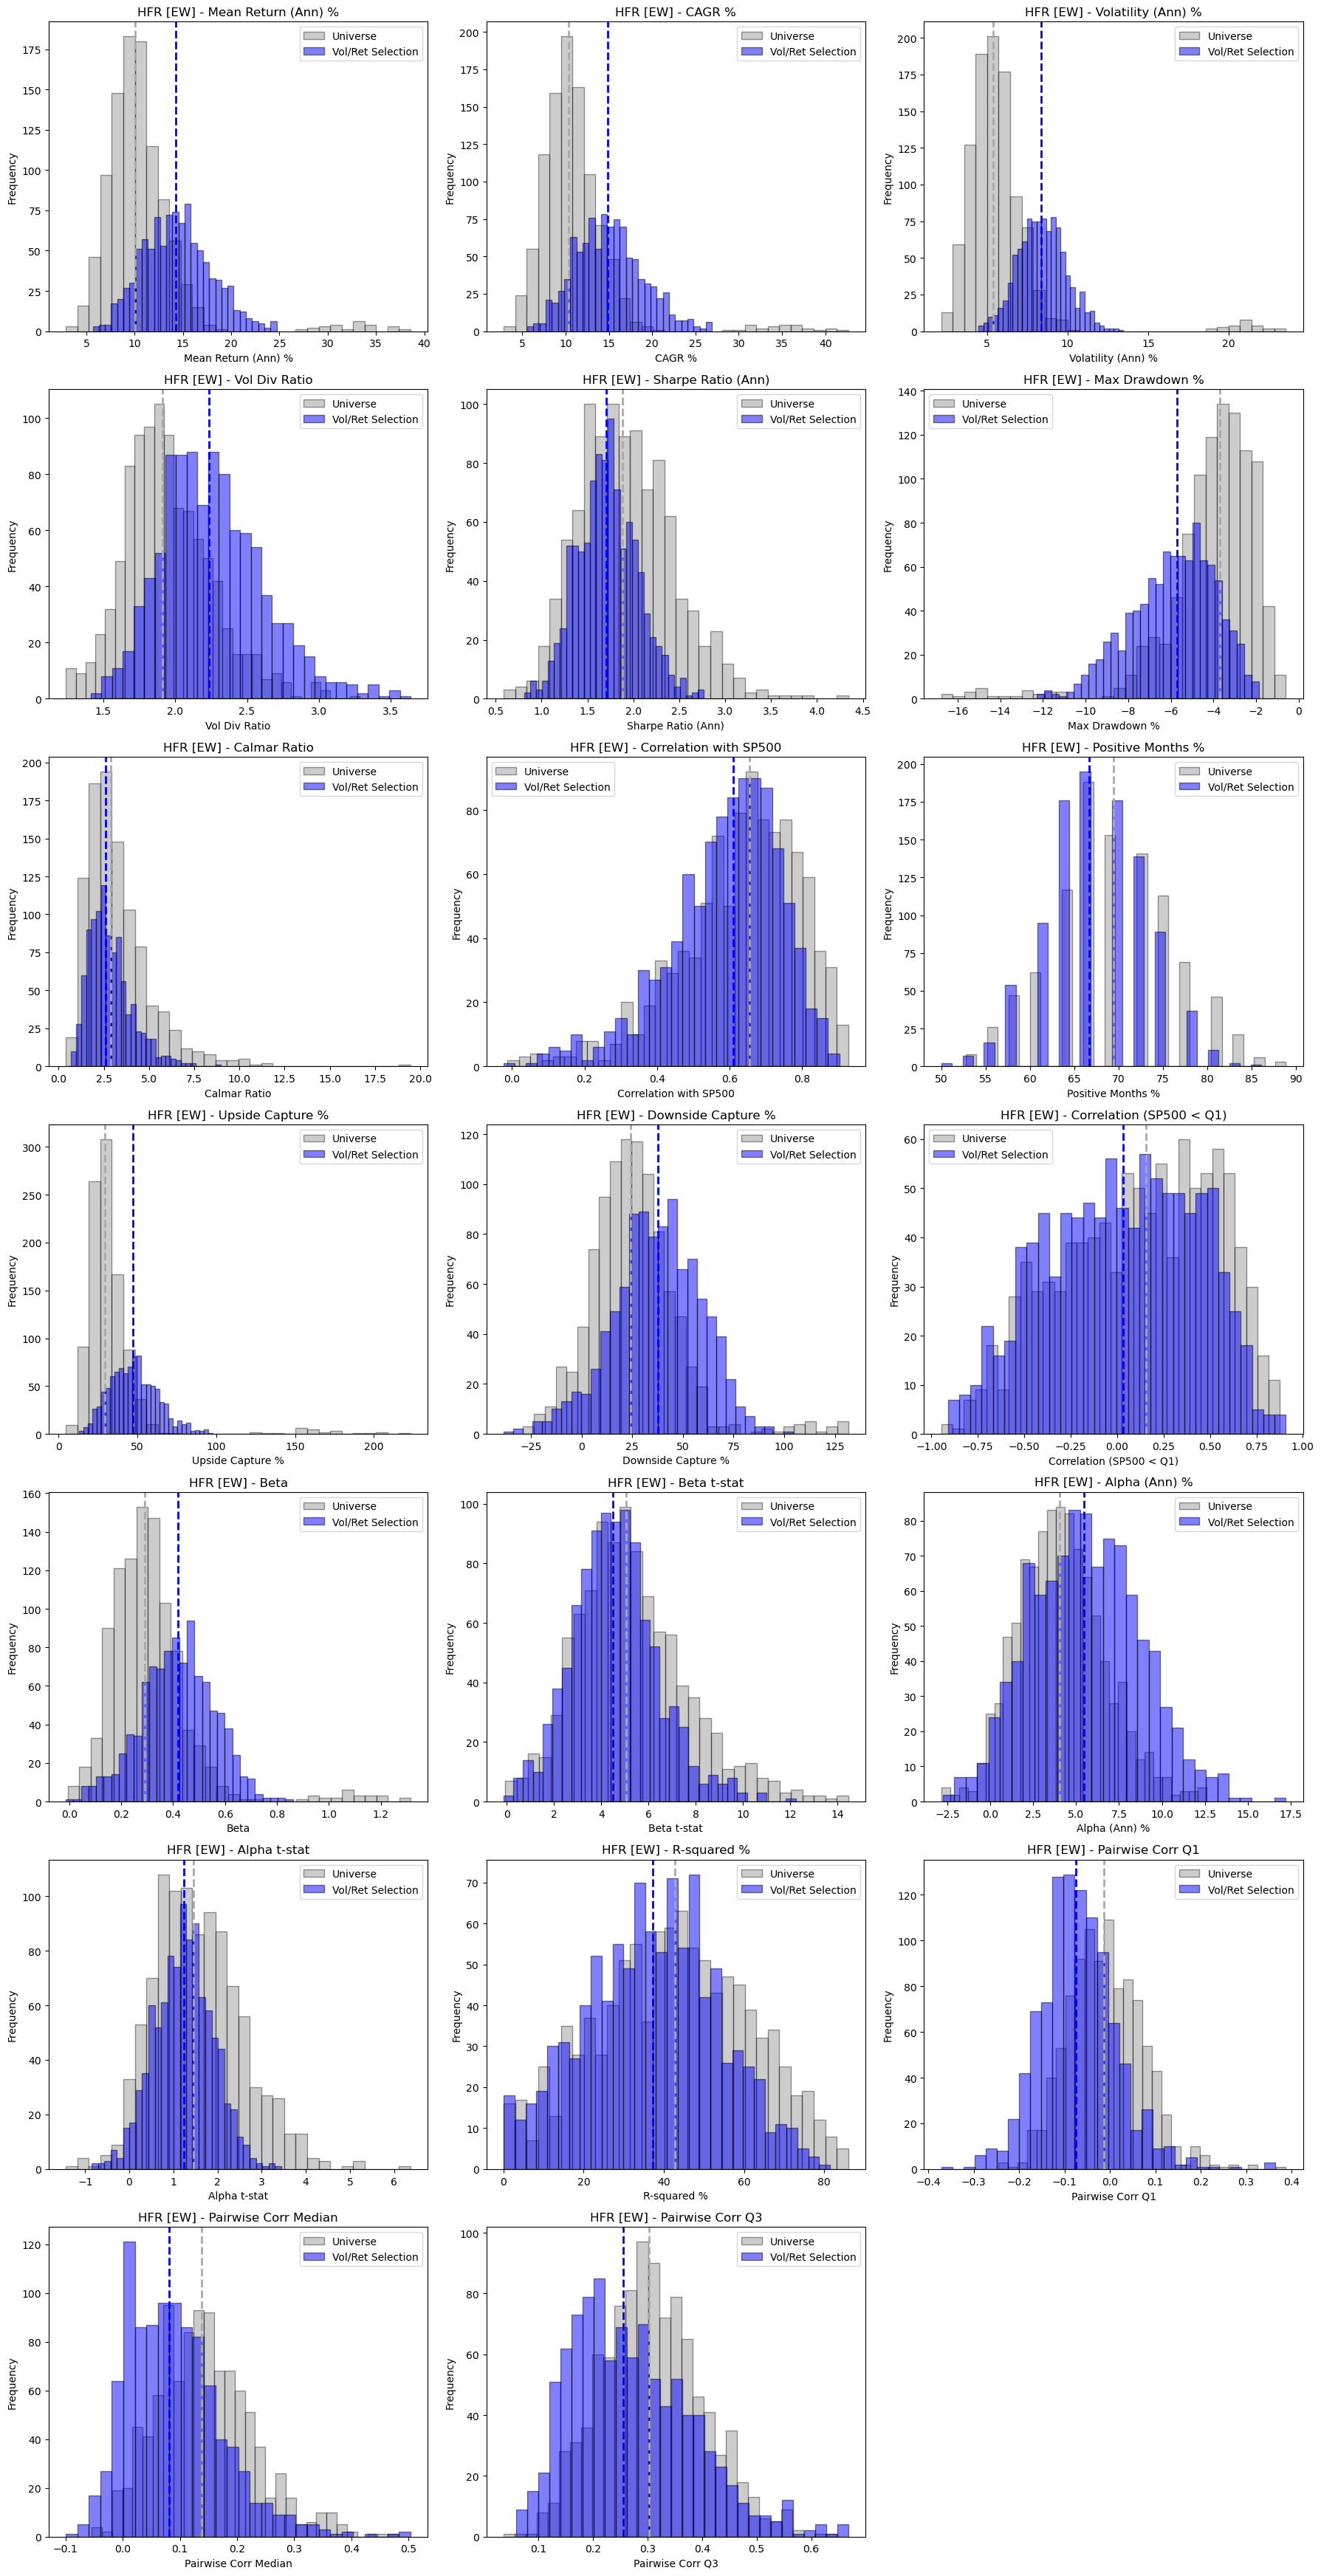

In [15]:
print("HFR EW: Vol/Ret Selection vs Universe Boxplots")
plot_universe_comparison_box(res_hfr_10_ew, res_hfr_10_ew_universe, "HFR", "EW")

print("HFR EW: Vol/Ret Selection vs Universe Overlaid Histograms")
plot_universe_comparison_hist(res_hfr_10_ew, res_hfr_10_ew_universe, "HFR", "EW")


## 8. Summary Table: Top 20% vs Universe

In [16]:
def create_universe_comparison_table(res_jpm_sel, res_hfr_sel, res_jpm_uni, res_hfr_uni, weight_scheme):
    datasets = {
        ('JPM', 'Vol/Ret Selection'): res_jpm_sel,
        ('JPM', 'Universe'): res_jpm_uni,
        ('HFR', 'Vol/Ret Selection'): res_hfr_sel,
        ('HFR', 'Universe'): res_hfr_uni
    }
    
    summary_data = {}
    
    for (data_name, approach), df in datasets.items():
        if df.empty:
            continue
            
        for metric in metrics_to_plot:
            median = df[metric].median()
            summary_data[(data_name, weight_scheme, approach, metric)] = median
            
    summary_series = pd.Series(summary_data)
    summary_series.index.names = ['Dataset', 'Weighting', 'Approach', 'Metric']
    summary_df = summary_series.unstack(level=['Dataset', 'Weighting', 'Approach'])
    
    # Safely reindex keeping existing columns 
    available_datasets = [d for d in ['JPM', 'HFR'] if d in summary_df.columns.get_level_values('Dataset')]
    available_approaches = [a for a in ['Vol/Ret Selection', 'Universe'] if a in summary_df.columns.get_level_values('Approach')]
    
    summary_df = summary_df.reindex(columns=available_datasets, level='Dataset')
    summary_df = summary_df.reindex(columns=available_approaches, level='Approach')
    summary_df = summary_df.reindex(metrics_to_plot)
    
    return summary_df

comp_table_ew = create_universe_comparison_table(res_jpm_10_ew, res_hfr_10_ew, res_jpm_10_ew_universe, res_hfr_10_ew_universe, 'EW')
comp_table_iv = create_universe_comparison_table(res_jpm_10_iv, res_hfr_10_iv, res_jpm_10_iv_universe, res_hfr_10_iv_universe, 'IV')

# Combine EW and IV for a massive final comparison table
final_comparison = pd.concat([comp_table_ew, comp_table_iv], axis=1)
display(final_comparison.round(2))


Dataset                                JPM                        HFR  \
Weighting                               EW                         EW   
Approach                 Vol/Ret Selection Universe Vol/Ret Selection   
Metric                                                                  
Mean Return (Ann) %                  13.75    10.49             14.25   
CAGR %                               14.39    10.88             14.84   
Volatility (Ann) %                    7.14     4.48              8.38   
Vol Div Ratio                         1.96     1.95              2.23   
Sharpe Ratio (Ann)                    1.91     2.36              1.71   
Max Drawdown %                       -5.60    -2.75             -5.70   
Calmar Ratio                          2.61     3.91              2.60   
Correlation with SP500                0.69     0.66              0.61   
Positive Months %                    69.44    75.00             66.67   
Upside Capture %                     44.92    28.47             47.06   
Downside Capture %                   38.67    13.73             37.76   
Correlation (SP500 < Q1)              0.41     0.31              0.03   
Beta                                  0.40     0.25              0.42   
Beta t-stat                           5.51     5.17              4.48   
Alpha (Ann) %                         5.09     5.26              5.46   
Alpha t-stat                          1.49     2.47              1.24   
R-squared %                          47.20    44.03             37.15   
Pairwise Corr Q1                     -0.07    -0.03             -0.08   
Pairwise Corr Median                  0.10     0.12              0.08   
Pairwise Corr Q3                      0.28     0.28              0.25   

Dataset                                         JPM           \
Weighting                                        IV            
Approach                 Universe Vol/Ret Selection Universe   
Metric                                                         
Mean Return (Ann) %         10.06             11.02     9.07   
CAGR %                      10.39             11.48     9.41   
Volatility (Ann) %           5.40              4.74     2.75   
Vol Div Ratio                1.91              2.90     3.17   
Sharpe Ratio (Ann)           1.88              2.21     3.30   
Max Drawdown %              -3.68             -3.06    -1.23   
Calmar Ratio                 2.88              3.65     7.48   
Correlation with SP500       0.65              0.63     0.64   
Positive Months %           69.44             72.22    83.33   
Upside Capture %            29.65             30.15    21.15   
Downside Capture %          24.09             14.79    -3.14   
Correlation (SP500 < Q1)     0.15              0.35     0.32   
Beta                         0.29              0.25     0.14   
Beta t-stat                  5.04              4.77     4.81   
Alpha (Ann) %                4.03              5.47     6.17   
Alpha t-stat                 1.45              2.20     4.30   
R-squared %                 42.77             40.13    40.45   
Pairwise Corr Q1            -0.01             -0.07    -0.03   
Pairwise Corr Median         0.14              0.10     0.12   
Pairwise Corr Q3             0.30              0.28     0.28   

Dataset                                HFR           
Weighting                               IV           
Approach                 Vol/Ret Selection Universe  
Metric                                               
Mean Return (Ann) %                  12.61     8.46  
CAGR %                               13.08     8.75  
Volatility (Ann) %                    6.67     2.75  
Vol Div Ratio                         2.78     3.68  
Sharpe Ratio (Ann)                    1.88     3.04  
Max Drawdown %                       -4.24    -1.37  
Calmar Ratio                          3.09     6.31  
Correlation with SP500                0.68     0.68  
Positive Months %                    69.44    80.56  
Upside C

Top 25% Sharpe Volatility Distribution - EW


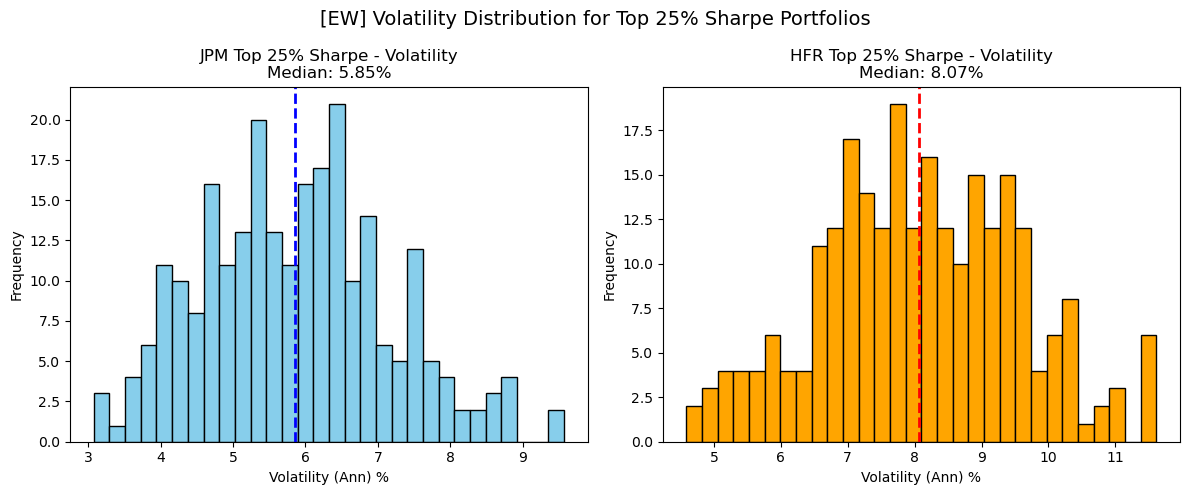

Top 25% Sharpe Volatility Distribution - IV


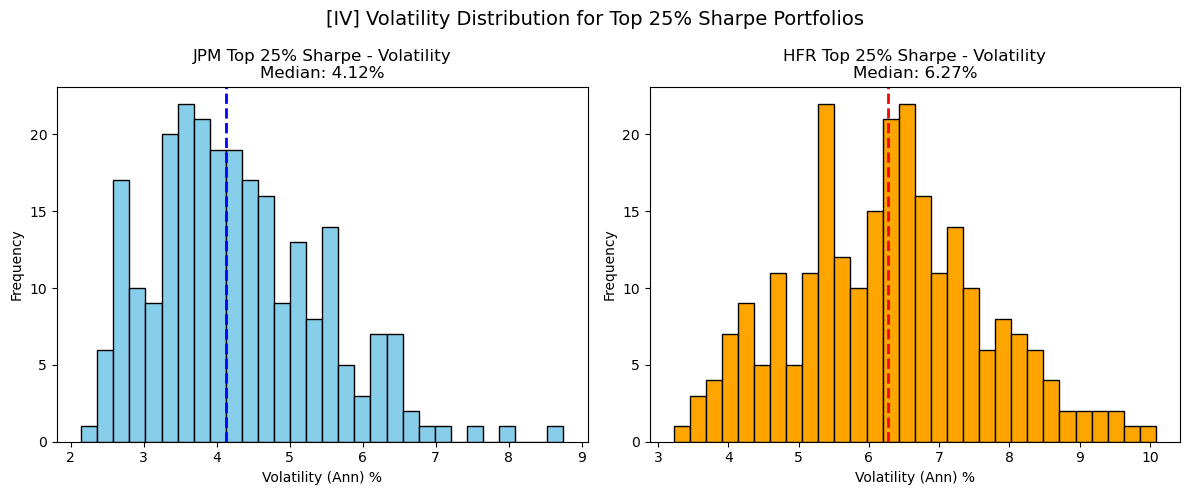

In [17]:
def plot_top_25_sharpe_vol_distribution(res_jpm, res_hfr, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # JPM
    if not res_jpm.empty:
        q75_jpm = res_jpm['Sharpe Ratio (Ann)'].quantile(0.75)
        top_25_jpm = res_jpm[res_jpm['Sharpe Ratio (Ann)'] >= q75_jpm]
        axes[0].hist(top_25_jpm['Volatility (Ann) %'].dropna(), bins=30, color='skyblue', edgecolor='black')
        axes[0].axvline(top_25_jpm['Volatility (Ann) %'].median(), color='blue', linestyle='dashed', linewidth=2)
        axes[0].set_title(f'JPM Top 25% Sharpe - Volatility\nMedian: {top_25_jpm["Volatility (Ann) %"].median():.2f}%')
        axes[0].set_xlabel('Volatility (Ann) %')
        axes[0].set_ylabel('Frequency')
        
    # HFR
    if not res_hfr.empty:
        q75_hfr = res_hfr['Sharpe Ratio (Ann)'].quantile(0.75)
        top_25_hfr = res_hfr[res_hfr['Sharpe Ratio (Ann)'] >= q75_hfr]
        axes[1].hist(top_25_hfr['Volatility (Ann) %'].dropna(), bins=30, color='orange', edgecolor='black')
        axes[1].axvline(top_25_hfr['Volatility (Ann) %'].median(), color='red', linestyle='dashed', linewidth=2)
        axes[1].set_title(f'HFR Top 25% Sharpe - Volatility\nMedian: {top_25_hfr["Volatility (Ann) %"].median():.2f}%')
        axes[1].set_xlabel('Volatility (Ann) %')
        axes[1].set_ylabel('Frequency')
        
    fig.suptitle(f'{title_prefix} Volatility Distribution for Top 25% Sharpe Portfolios', fontsize=14)
    plt.tight_layout()
    plt.show()

print("Top 25% Sharpe Volatility Distribution - EW")
if 'res_jpm_10_ew' in locals() and 'res_hfr_10_ew' in locals():
    plot_top_25_sharpe_vol_distribution(res_jpm_10_ew, res_hfr_10_ew, "[EW]")

print("Top 25% Sharpe Volatility Distribution - IV")
if 'res_jpm_10_iv' in locals() and 'res_hfr_10_iv' in locals():
    plot_top_25_sharpe_vol_distribution(res_jpm_10_iv, res_hfr_10_iv, "[IV]")
